# EstateIQ

## Indian Real Estate Market Intelligence & Property Valuation

EstateIQ is an end-to-end real estate analytics project built to
understand residential property markets using real-world listing data.

The project uses property listings from the 99acres real-estate dataset
covering major Indian markets including Gurgaon, Hyderabad, Kolkata and
Mumbai.

### Project Goals

- Understand the structure and quality of real-estate listing data.
- Clean and standardize property information.
- Analyze property prices and price per square foot.
- Compare cities and localities.
- Study the relationship between property characteristics and price.
- Analyze amenities, furnishing, property type and other attributes.
- Engineer meaningful real-estate features.
- Build and compare machine-learning valuation models.
- Explain model predictions using SHAP.
- Estimate model-based fair property values.
- Identify potentially underpriced and overpriced listings.
- Build an interactive Streamlit application.

### Core Business Questions

1. Which markets have the highest property prices?
2. Which localities have the highest price per square foot?
3. How does property size affect price?
4. How do BHK, bathrooms and furnishing affect property value?
5. Which property characteristics are most important for valuation?
6. How accurately can machine learning estimate property prices?
7. What factors drive individual valuation predictions?
8. Which listings appear potentially underpriced relative to model-estimated value?

### Data Source

Indian Real Estate - 99acres.com

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from scipy import stats

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.max_colwidth", 100)

sns.set_theme(style="whitegrid")

print("EstateIQ environment ready.")


EstateIQ environment ready.


In [2]:
PROJECT_ROOT = Path.cwd().parent

RAW_DATA_DIR = PROJECT_ROOT / "data" / "raw"
PROCESSED_DATA_DIR = PROJECT_ROOT / "data" / "processed"
MODELS_DIR = PROJECT_ROOT / "models"

PROCESSED_DATA_DIR.mkdir(
    parents=True,
    exist_ok=True
)

MODELS_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print("Project Root:")
print(PROJECT_ROOT)

print("\nRaw Data:")
print(RAW_DATA_DIR)

print("\nProcessed Data:")
print(PROCESSED_DATA_DIR)

print("\nModels:")
print(MODELS_DIR)


Project Root:
c:\Users\Devendra Upadhyay\OneDrive\Desktop\Estateiq-real-estate-analytics

Raw Data:
c:\Users\Devendra Upadhyay\OneDrive\Desktop\Estateiq-real-estate-analytics\data\raw

Processed Data:
c:\Users\Devendra Upadhyay\OneDrive\Desktop\Estateiq-real-estate-analytics\data\processed

Models:
c:\Users\Devendra Upadhyay\OneDrive\Desktop\Estateiq-real-estate-analytics\models


In [3]:
property_files = {
    "Gurgaon": RAW_DATA_DIR / "gurgaon_10k.csv",
    "Hyderabad": RAW_DATA_DIR / "hyderabad.csv",
    "Kolkata": RAW_DATA_DIR / "kolkata.csv",
    "Mumbai": RAW_DATA_DIR / "mumbai.csv"
}

for city, file_path in property_files.items():
    print(
        f"{city:12} → "
        f"{file_path} "
        f"{'✓' if file_path.exists() else '✗ NOT FOUND'}"
    )


Gurgaon      → c:\Users\Devendra Upadhyay\OneDrive\Desktop\Estateiq-real-estate-analytics\data\raw\gurgaon_10k.csv ✓
Hyderabad    → c:\Users\Devendra Upadhyay\OneDrive\Desktop\Estateiq-real-estate-analytics\data\raw\hyderabad.csv ✓
Kolkata      → c:\Users\Devendra Upadhyay\OneDrive\Desktop\Estateiq-real-estate-analytics\data\raw\kolkata.csv ✓
Mumbai       → c:\Users\Devendra Upadhyay\OneDrive\Desktop\Estateiq-real-estate-analytics\data\raw\mumbai.csv ✓


In [4]:
raw_data = {}

for city, file_path in property_files.items():

    df_city = pd.read_csv(
        file_path,
        low_memory=False
    )

    raw_data[city] = df_city

    print(
        f"{city:12} | "
        f"Rows: {df_city.shape[0]:,} | "
        f"Columns: {df_city.shape[1]}"
    )


Gurgaon      | Rows: 10,704 | Columns: 67
Hyderabad    | Rows: 9,487 | Columns: 55
Kolkata      | Rows: 8,797 | Columns: 35
Mumbai       | Rows: 9,514 | Columns: 55


In [5]:
schema_summary = []

for city, df_city in raw_data.items():

    schema_summary.append({
        "City": city,
        "Rows": df_city.shape[0],
        "Columns": df_city.shape[1],
        "Missing_Cells": int(
            df_city.isna().sum().sum()
        ),
        "Duplicate_Rows": int(
            df_city.duplicated().sum()
        )
    })

schema_summary = pd.DataFrame(
    schema_summary
)

schema_summary


,City,Rows,Columns,Missing_Cells,Duplicate_Rows
0,Gurgaon,10704,67,74862,0
1,Hyderabad,9487,55,32678,0
2,Kolkata,8797,35,50558,0
3,Mumbai,9514,55,22754,0


In [6]:
all_columns = {}

for city, df_city in raw_data.items():
    all_columns[city] = set(df_city.columns)

for city, columns in all_columns.items():

    print("\n" + "=" * 80)
    print(city)
    print("=" * 80)

    print(
        f"Number of columns: {len(columns)}"
    )

    print("\nColumns:")

    for column in sorted(columns):
        print(f"  • {column}")



Gurgaon
Number of columns: 67

Columns:
  • AGE
  • AMENITIES
  • AREA
  • BALCONY_NUM
  • BATHROOM_NUM
  • BEDROOM_NUM
  • BROKERAGE
  • BUILDING_ID
  • BUILDING_NAME
  • BUILTUP_SQFT
  • CARPET_SQFT
  • CITY
  • CITY_ID
  • CLASS_HEADING
  • CLASS_LABEL
  • COMMON_FURNISHING_ATTRIBUTES
  • CONTACT_COMPANY_NAME
  • CONTACT_NAME
  • DEALER_PHOTO_URL
  • DESCRIPTION
  • EXPIRY_DATE
  • FACING
  • FEATURES
  • FLOOR_NUM
  • FORMATTED
  • FORMATTED_LANDMARK_DETAILS
  • FSL_Data
  • FURNISH
  • FURNISHING_ATTRIBUTES
  • GROUP_NAME
  • LISTING
  • LOCALITY
  • LOCALITY_WO_CITY
  • MAP_DETAILS
  • MAX_AREA_SQFT
  • MAX_PRICE
  • MEDIUM_PHOTO_URL
  • MIN_AREA_SQFT
  • MIN_PRICE
  • OWNTYPE
  • PD_URL
  • PHOTO_URL
  • PREFERENCE
  • PRICE
  • PRICE_PER_UNIT_AREA
  • PRICE_SQFT
  • PROPERTY_IMAGES
  • PROPERTY_TYPE
  • PROP_DETAILS_URL
  • PROP_HEADING
  • PROP_ID
  • PROP_NAME
  • QUALITY_SCORE
  • REGISTER_DATE
  • SECONDARY_TAGS
  • SOCIETY_NAME
  • SUPERBUILTUP_SQFT
  • SUPER_SQFT
  • THU

In [7]:
common_columns = set.intersection(
    *all_columns.values()
)

print(
    f"Common columns across all four datasets: "
    f"{len(common_columns)}"
)

for column in sorted(common_columns):
    print(f"• {column}")


Common columns across all four datasets: 29
• AGE
• AMENITIES
• AREA
• BALCONY_NUM
• BEDROOM_NUM
• BUILDING_NAME
• CITY
• DESCRIPTION
• FACING
• FEATURES
• FLOOR_NUM
• FORMATTED_LANDMARK_DETAILS
• FURNISH
• MAP_DETAILS
• OWNTYPE
• PREFERENCE
• PRICE
• PRICE_PER_UNIT_AREA
• PRICE_SQFT
• PROPERTY_TYPE
• PROP_HEADING
• PROP_ID
• PROP_NAME
• SECONDARY_TAGS
• SOCIETY_NAME
• TOTAL_FLOOR
• TOTAL_LANDMARK_COUNT
• TRANSACT_TYPE
• location


In [8]:
for city, columns in all_columns.items():

    other_columns = set.union(
        *[
            cols
            for other_city, cols in all_columns.items()
            if other_city != city
        ]
    )

    unique_columns = columns - other_columns

    print(
        f"\n{city} unique columns:"
    )

    if unique_columns:
        for column in sorted(unique_columns):
            print(f"  • {column}")
    else:
        print("  None")



Gurgaon unique columns:
  • BATHROOM_NUM
  • BROKERAGE
  • CITY_ID
  • COMMON_FURNISHING_ATTRIBUTES
  • CONTACT_COMPANY_NAME
  • CONTACT_NAME
  • DEALER_PHOTO_URL
  • FORMATTED
  • FSL_Data
  • FURNISHING_ATTRIBUTES
  • GROUP_NAME
  • LISTING
  • LOCALITY
  • LOCALITY_WO_CITY
  • MEDIUM_PHOTO_URL
  • PD_URL
  • PHOTO_URL
  • PROPERTY_IMAGES
  • PROP_DETAILS_URL
  • QUALITY_SCORE
  • THUMBNAIL_IMAGES
  • metadata
  • profile
  • xid

Hyderabad unique columns:
  None

Kolkata unique columns:
  • SUPERAREA_UNIT
  • SUPER_AREA

Mumbai unique columns:
  None


In [9]:
for city, df_city in raw_data.items():

    print("\n" + "=" * 100)
    print(f"{city.upper()} — SAMPLE")
    print("=" * 100)

    display(
        df_city.head()
    )



GURGAON — SAMPLE


,PROP_ID,PHOTO_URL,MEDIUM_PHOTO_URL,PREFERENCE,DESCRIPTION,PROPERTY_TYPE,CITY,LOCALITY,TRANSACT_TYPE,OWNTYPE,BEDROOM_NUM,BATHROOM_NUM,BALCONY_NUM,PRICE_PER_UNIT_AREA,FURNISH,FACING,AGE,FLOOR_NUM,TOTAL_FLOOR,FEATURES,REGISTER_DATE,PROP_NAME,MIN_PRICE,MAX_PRICE,PRICE_SQFT,LISTING,BUILDING_ID,CARPET_SQFT,SUPERBUILTUP_SQFT,BROKERAGE,MAP_DETAILS,FSL_Data,MIN_AREA_SQFT,MAX_AREA_SQFT,FORMATTED,AMENITIES,TOP_USPS,PD_URL,EXPIRY_DATE,GROUP_NAME,AREA,PRICE,PROP_HEADING,PROP_DETAILS_URL,CLASS_HEADING,CLASS_LABEL,SECONDARY_TAGS,PROPERTY_IMAGES,THUMBNAIL_IMAGES,TOTAL_LANDMARK_COUNT,FORMATTED_LANDMARK_DETAILS,CONTACT_NAME,CONTACT_COMPANY_NAME,DEALER_PHOTO_URL,SOCIETY_NAME,BUILDING_NAME,CITY_ID,LOCALITY_WO_CITY,profile,xid,metadata,location,BUILTUP_SQFT,SUPER_SQFT,COMMON_FURNISHING_ATTRIBUTES,QUALITY_SCORE,FURNISHING_ATTRIBUTES
0,O71585872,https://mediacdn.99acres.com/media1/22409/13/448193438T-1695986883020.jpg,https://mediacdn.99acres.com/media1/22409/13/448193438M-1695986883166.jpg,S,4 bhk flat for resale in alpha corp gurgaon one,Residential Apartment,Gurgaon,Sector 84 Gurgaon,1.0,1,4.0,4,4.0,8766.0,4,1,2,14,26.0,"33,23,12,46,25,47,39,1,3,6,9,40,41,30,20,42,21,32","29th Sep, 2023",Alpha Corp GurgaonOne 84,26300000,26300000,8766.0,R,10532,3000.0,3434.0,263000.0,"{'LATITUDE': '28.4065341', 'LONGITUDE': '76.9627918', 'ZOOM_LEVEL': '14', 'SOURCE': 'BUILDING', ...",{'LOCALITY_ID': 0},319.028902,319.028902,"{'AVAIL': {'AVAILABILITY': 2, 'SUB_AVAILABILITY': '2', 'AVAILABILITY_DATE': ''}, 'AVG_PRICE': '2...","20,21,32,23,46,47,39,1,6,9,40,41,30,42,33,12,25,3,102","['North Facing', 'Recently Renovated', 'Gated Society', 'Corner Property']",/4-bhk-bedroom-apartment-flat-for-sale-in-alpha-corp-gurgaonone-84-sector-84-gurgaon-3434-sq-ft-...,2023-11-28 00:00:00,SPID_GROUP_SEARCH_NORMAL,3434 sq.ft.,2.63 Cr,4 BHK Flat in Sector 84 Gurgaon,4-bhk-bedroom-apartment-flat-for-sale-in-alpha-corp-gurgaonone-84-sector-84-gurgaon-3434-sq-ft-s...,Dealer: propertyline,Dealer,"['READY TO MOVE', 'RESALE']","['https://mediacdn.99acres.com/media1/22409/13/448193438M-1695986883166.jpg', 'https://mediacdn....","['https://mediacdn.99acres.com/media1/22409/13/448193438T-1695986883020.jpg', 'https://mediacdn....",10.0,"[{'category': 'Shopping', 'text': '4 Shoppings', 'className': 'shpng', 'icon': 'https://static.9...",gaurav khosla,propertyline,https://static.99acres.com/images/dealer_pnava.png,Alpha Corp GurgaonOne 84,Alpha Corp GurgaonOne 84,8,Sector 84,"{'CONTACT_NAME': 'gaurav khosla', 'CONTACT_COMPANY_NAME': 'propertyline', 'CLASS_LABEL': 'A', 'C...","{'PROJECTID': 5096, 'PROJ_NAME': 'Alpha Corp GurgaonOne 84', 'BUILDERID': 3236, 'SEO_BUILDER_URL...","{'PROP_PHOTO_COUNT': '4', 'PROP_VIDEO_COUNT': '0'}","{'CITY': '8', 'CITY_NAME': 'Gurgaon', 'BUILDING_ID': '10532', 'BUILDING_NAME': 'Alpha Corp Gurga...",NaN,NaN,NaN,NaN,NaN
1,T71585466,https://mediacdn.99acres.com/media1/22425/6/448506698T-1696148859724.jpg,https://mediacdn.99acres.com/media1/22425/6/448506698M-1696148859950.jpg,S,"Explore dlf ultima, an upscale ready-To-Move home society nestled in gurgaon's sector 81. Develo...",Residential Apartment,Gurgaon,Sector 81 Gurgaon,1.0,1,4.0,4,3.0,21176.0,4,1,1,7,29.0,"44,33,23,12,46,25,47,26,17,29,19,1,3,5,6,9,30,41,20,21,10,43","29th Sep, 2023",DLF The Ultima,36000000,36000000,21176.0,R,12704,1700.0,2870.0,1.0,"{'LATITUDE': '28.3889069', 'LONGITUDE': '76.9513279', 'ZOOM_LEVEL': '14', 'SOURCE': 'BUILDING', ...",{'LOCALITY_ID': 0},266.631610,266.631610,"{'AVAIL': {'AVAILABILITY': 2, 'SUB_AVAILABILITY': '1', 'AVAILABILITY_DATE': ''}, 'AVG_PRICE': '3...","17,5,20,21,10,44,23,46,47,29,19,1,6,9,30,41,43,33,12,25,26,3,101,102,103","['North Facing', ""st. xavier's within 500m"", 'apollo miracle within 1km', 'Gated Society']",/4-bhk-bedroom-apartment-flat-for-sale-in-dlf-the-ultima-sector-81-gurgaon-2870-sq-ft-spid-T7158...,2023-11-28 00:00:00,SPID_GROUP_SEARCH_NORMAL,2870 sq.ft.,3.6 Cr,4 BHK Flat in Sector 81 Gurgaon,4-bhk-bedroom-apartment-flat-for-sale-in-dlf-the-ultima-sector-


HYDERABAD — SAMPLE


,SPID,PROP_ID,PREFERENCE,DESCRIPTION,PROPERTY_TYPE,CITY,TRANSACT_TYPE,OWNTYPE,BEDROOM_NUM,PRICE_PER_UNIT_AREA,FURNISH,FACING,AGE,TOTAL_FLOOR,FEATURES,REGISTER_DATE,POSTING_DATE,UPDATE_DATE,CLASS,RES_COM,PROP_NAME,PROPERTY_NUMBER,MIN_PRICE,MAX_PRICE,PRICE_SQFT,PROJ_ID,BUILDING_ID,VERIFIED,MAP_DETAILS,MIN_AREA_SQFT,MAX_AREA_SQFT,AMENITIES,ALT_TAG,PRODUCT_TYPE,TOP_USPS,EXPIRY_DATE,PROPERTY_TYPE__U,AREA,SECONDARY_AREA,PRICE,PROP_HEADING,VALUE_LABEL,CLASS_HEADING,CLASS_LABEL,REGISTER_DATE__U,REGISTERED_DAYS,PRIMARY_TAGS,SECONDARY_TAGS,TOTAL_LANDMARK_COUNT,FORMATTED_LANDMARK_DETAILS,SOCIETY_NAME,BUILDING_NAME,location,BALCONY_NUM,FLOOR_NUM
0,70135726,Z70135726,S,"Hmda, rera approved residential apartments at kompally town, close to all international schools,...",Residential Apartment,Secunderabad,1.0,1,2.0,5700.0,2,4,1,5.0,"23,24,5,17,6,20,21","08th Jul, 2023",1.688834e+12,1689100520000,A,R,Evolve,1,6925500,6925500,5700.0,0,0,N,"{'LATITUDE': '17.575957', 'LONGITUDE': '78.471167'}",112.877145,112.877145,"5,17,20,21,23,24,6","₹69.25 Lac, 2 bhk Residential Apartment in Gundlapochampalli - Entrance",PREMIUM_LISTING,NaN,2023-09-06 00:00:00,1,1215 sq.ft.,112.88 sq.m.,69.25 L,2 BHK Flat in Gundlapochampalli,Freehold,Dealer: Rainbow Developers,Dealer,2023-07-08 22:01:14,1 month ago,['FEATURED'],"['READY TO MOVE', 'RESALE']",9.0,[{'text': '1 Library'}],Evolve,Evolve,"{'CITY': '268', 'CITY_NAME': 'Secunderabad', 'BUILDING_ID': '0', 'BUILDING_NAME': 'Evolve', 'SOC...",1.0,2
1,68489968,A68489968,S,"Own a 2 BHK apartment in Annes Fortune Greenhomes Swan, Nizampet, Hyderabad for a comfortable li...",Residential Apartment,Hyderabad,2.0,1,2.0,6000.0,0,0,5,20.0,N,"12th Apr, 2023",1.681280e+12,1681280381000,B,R,Annes Fortune Greenhomes Swan,8,6930000,8370000,6000.0,400617,1093625,N,"{'LATITUDE': '17.522103', 'LONGITUDE': '78.384846'}",107.302965,129.599685,NaN,Annes Fortune Greenhomes Swan Others,PSEUDO_LISTING,NaN,2023-10-09 00:00:00,1,1155-1395 sq.ft.,107.3-129.6 sq.m.,69.3 - 83.7 L,2 BHK Flat in Nizampet,Freehold,Builder,Builder,2023-04-12 11:49:40,4 months ago,['FEATURED'],"['UNDER CONSTRUCTION', 'NEW BOOKING', 'RERA']",50.0,"[{'text': '1 Shopping'}, {'text': '3 Religious Places'}, {'text': '9 ATMs'}, {'text': '14 Hospit...",Annes Fortune Greenhomes Swan,Annes Fortune Greenhomes Swan,"{'CITY': '269', 'CITY_NAME': 'Hyderabad', 'BUILDING_ID': '1093625', 'BUILDING_NAME': 'Annes Fort...",NaN,1
2,69555358,M69555358,S,"This well-known project offers 4 BHK apartments in Nanakramguda, Hyderabad. With a super built-u...",Residential Apartment,Hyderabad,2.0,1,4.0,0.0,0,0,5,20.0,N,"08th Jun, 2023",1.686226e+12,1686225628000,B,R,The Olympus,2,0,0,0.0,378897,1061980,N,"{'LATITUDE': '17.41977', 'LONGITUDE': '78.34969'}",267.560640,278.709000,NaN,The Olympus Others,PSEUDO_LISTING,NaN,2023-12-05 00:00:00,1,2880-3000 sq.ft.,267.56-278.71 sq.m.,Price on Request,4 BHK Flat in Nanakramguda,Freehold,Builder,Builder,2023-06-08 17:30:28,2 months ago,[],"['UNDER CONSTRUCTION', 'NEW BOOKING', 'RERA']",11.0,"[{'text': '1 Metro Station'}, {'text': '1 Shopping'}, {'text': '1 Connectivity'}, {'text': '2 Ed...",The Olympus,The Olympus,"{'CITY': '269', 'CITY_NAME': 'Hyderabad', 'BUILDING_ID': '1061980', 'BUILDING_NAME': 'The Olympu...",NaN,1
3,69555352,P69555352,S,Enjoy a blissful living experience in The Olympus. This residential project encompasses 3 BHK fl...,Residential Apartment,Hyderabad,2.0,1,3.0,20049.0,0,0,5,20.0,N,"08th Jun, 2023",1.686226e+12,1686225627000,B,R,The Olympus,2,20200000,20200000,20049.0,378897,1061980,N,"{'LATITUDE': '17.41977', 'LONGITUDE': '78.34969'}",186.735030,187.664060,NaN,The Olympus Others,PSEUDO_LISTING,NaN,2023-12-05 00:00:00,1,2010-2020 sq.ft.,186.74-187.66 sq.m.,2.02 - 2.02 Cr,3 BHK Flat in Nanakramguda,Freehold,Builder,Builder,2023-06-08 17:30:27,2 months ago,[],"['UNDER CONSTRUCTION', 'NEW BOOKING', 'RERA']",11.0,"[{'text': '1 Metro Station'}, {'text': '1 Shopping'}, {'text': '1 Connectivity'}, {'text': '2 Ed...",The Olympus,The Olympus,"


KOLKATA — SAMPLE


,PROP_ID,PREFERENCE,DESCRIPTION,PROPERTY_TYPE,CITY,TRANSACT_TYPE,OWNTYPE,BEDROOM_NUM,PRICE_PER_UNIT_AREA,FURNISH,FACING,AGE,TOTAL_FLOOR,FEATURES,PROP_NAME,PRICE_SQFT,MAP_DETAILS,AMENITIES,AREA,PRICE,PROP_HEADING,SECONDARY_TAGS,TOTAL_LANDMARK_COUNT,FORMATTED_LANDMARK_DETAILS,SOCIETY_NAME,BUILDING_NAME,location,BALCONY_NUM,FLOOR_NUM,CARPET_SQFT,SUPERBUILTUP_SQFT,BUILTUP_SQFT,SUPER_AREA,SUPERAREA_UNIT,SUPER_SQFT
0,Y71306776,S,"Book your 2 BHK flat in Srijan Star Swapno Puron, Amtala , Kolkata South. Having a super built-u...",Residential Apartment,Kolkata South,2.0,1,2.0,3662.0,0,0,5,3.0,N,Srijan Star Swapno Puron,3662.0,"{'LATITUDE': '22.364447', 'LONGITUDE': '88.274642'}",NaN,518-623 sq.ft.,19.1 L Onwards,2 BHK Flat in Amtala,"['UNDER CONSTRUCTION', 'NEW BOOKING', 'RERA | HIRA']",2.0,"[{'category': 'Shopping', 'text': '1 Shopping', 'className': 'shpng', 'icon': 'https://static.99...",Srijan Star Swapno Puron,Srijan Star Swapno Puron,"{'CITY': '27', 'CITY_NAME': 'Kolkata South', 'LOCALITY_ID': '8005', 'LOCALITY_NAME': 'Amtala ', ...",NaN,1,NaN,NaN,NaN,NaN,NaN,NaN
1,B70113976,S,"Make Natural Quest your next home. This project offers 3 BHK flats in EM Bypass, Kolkata South. ...",Residential Apartment,Kolkata South,2.0,1,3.0,10500.0,0,0,5,11.0,N,Natural Quest,10500.0,"{'LATITUDE': '22.518795', 'LONGITUDE': '88.388439'}",NaN,1110-1121 sq.ft.,1.17 - 1.18 Cr,3 BHK Flat in EM Bypass,"['UNDER CONSTRUCTION', 'NEW LAUNCH', 'NEW BOOKING', 'RERA | HIRA']",9.0,"[{'category': 'MetroStation', 'text': '1 Metro Station', 'className': 'mstn', 'icon': 'https://s...",Natural Quest,Natural Quest,"{'CITY': '27', 'CITY_NAME': 'Kolkata South', 'LOCALITY_ID': '603', 'LOCALITY_NAME': 'EM Bypass',...",NaN,1,NaN,NaN,NaN,NaN,NaN,NaN
2,O70374510,S,"Book your 3 BHK apartment in Garia, Kolkata South at a price ranging from Rs. 1.22 Crore to Rs. ...",Residential Apartment,Kolkata South,2.0,1,3.0,8900.0,0,0,5,20.0,N,Ganguly 4Sight Eminence,8900.0,"{'LATITUDE': '22.5137646', 'LONGITUDE': '88.3666797'}",NaN,1376-1516 sq.ft.,1.22 - 1.35 Cr,3 BHK Flat in Garia,"['UNDER CONSTRUCTION', 'NEW LAUNCH', 'NEW BOOKING', 'RERA | HIRA']",6.0,"[{'category': 'Shopping', 'text': '1 Shopping', 'className': 'shpng', 'icon': 'https://static.99...",Ganguly 4Sight Eminence,Ganguly 4Sight Eminence,"{'CITY': '27', 'CITY_NAME': 'Kolkata South', 'LOCALITY_ID': '651', 'LOCALITY_NAME': 'Garia', 'AD...",NaN,1,NaN,NaN,NaN,NaN,NaN,NaN
3,Q69170182,S,"Dev bhumi in joka, kolkata south by ocean land developer is a residential project. \n \nDev bhum...",Residential Land,Kolkata South,2.0,1,NaN,208.0,0,0,0,0.0,N,Dev Bhumi,208.0,"{'LATITUDE': '22.45383', 'LONGITUDE': '88.249572'}",NaN,720-2880 sq.ft.,1.5 - 5.99 L,Residential land / Plot in Joka,"['READY TO MOVE', 'NEW BOOKING']",13.0,"[{'category': 'MetroStation', 'text': '2 Metro Stations', 'className': 'mstn', 'icon': 'https://...",Dev Bhumi,Dev Bhumi,"{'CITY': '27', 'CITY_NAME': 'Kolkata South', 'LOCALITY_ID': '844', 'LOCALITY_NAME': 'Joka', 'ADD...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,F69917588,S,Let your dream of owning a flat come true with DTC Sojon. It offers an exclusive range of 3 BHK ...,Residential Apartment,Kolkata South,2.0,1,3.0,5215.0,0,0,5,19.0,N,DTC Sojon,5215.0,"{'LATITUDE': '22.44213', 'LONGITUDE': '88.29551'}",NaN,1130-1460 sq.ft.,60 - 75 L,3 BHK Flat in Joka,"['UNDER CONSTRUCTION', 'NEW BOOKING']",11.0,"[{'category': 'MetroStation', 'text': '1 Metro Station', 'className': 'mstn', 'icon': 'https://s...",DTC Sojon,DTC Sojon,"{'CITY': '27', 'CITY_NAME': 'Kolkata South', 'LOCALITY_ID': '844', 'LOCALITY_NAME': 'Joka', 'ADD...",NaN,1,NaN,NaN,NaN,NaN,NaN,NaN



MUMBAI — SAMPLE


,SPID,PROP_ID,PREFERENCE,DESCRIPTION,PROPERTY_TYPE,CITY,TRANSACT_TYPE,OWNTYPE,BEDROOM_NUM,PRICE_PER_UNIT_AREA,FURNISH,FACING,AGE,TOTAL_FLOOR,FEATURES,REGISTER_DATE,POSTING_DATE,UPDATE_DATE,CLASS,RES_COM,PROP_NAME,PROPERTY_NUMBER,MIN_PRICE,MAX_PRICE,PRICE_SQFT,PROJ_ID,BUILDING_ID,VERIFIED,MAP_DETAILS,MIN_AREA_SQFT,MAX_AREA_SQFT,AMENITIES,ALT_TAG,PRODUCT_TYPE,TOP_USPS,EXPIRY_DATE,PROPERTY_TYPE__U,AREA,SECONDARY_AREA,PRICE,PROP_HEADING,VALUE_LABEL,CLASS_HEADING,CLASS_LABEL,REGISTER_DATE__U,REGISTERED_DAYS,PRIMARY_TAGS,SECONDARY_TAGS,TOTAL_LANDMARK_COUNT,FORMATTED_LANDMARK_DETAILS,SOCIETY_NAME,BUILDING_NAME,location,BALCONY_NUM,FLOOR_NUM
0,69306824,X69306824,S,New brand 3bhk farmhouse with 68 guntha land for sale just 10km from karjat.\n\nNewly constructe...,Farm House,Mumbai Beyond Thane,1.0,1,3.0,477941.0,1,4,6,1.0,"44,23,45,12,24,46,25,47,26,19,1,40,41,42,32","10th Aug, 2023",1.685042e+12,1691637879000,A,R,NaN,1,32500001,32500001,477941.0,0,0,N,"{'LATITUDE': '18.92343', 'LONGITUDE': '73.32514'}",6879.560053,6879.560053,"32,44,23,45,24,46,47,19,1,40,41,42,12,25,26,101,102,103","₹3.25 Crore, 3 bhk Farm House in Karjat - Others",PREMIUM_LISTING,NaN,2023-10-09 00:00:00,5,74051 sq.ft.,6879.56 sq.m.,3.25 Cr,3 Bedroom Farm house in Karjat,Freehold,Dealer: SRA Estate Consultant,Dealer,2023-08-10 08:54:39,2 weeks ago,['FEATURED'],"['READY TO MOVE', 'RESALE']",14.0,[{'text': '9 Hospitals'}],NaN,NaN,"{'CITY': '274', 'CITY_NAME': 'Mumbai Beyond Thane', 'BUILDING_ID': '0', 'BUILDING_NAME': '', 'SO...",1.0,NaN
1,70915032,R70915032,S,Our residential plots & commercial plots are available at the most affordable price. The progres...,Residential Land,Navi Mumbai,1.0,1,NaN,381.0,0,5,0,7.0,N,"20th Aug, 2023",1.692529e+12,1692528854000,A,R,city prop,1,415000,415000,381.0,0,0,N,"{'LATITUDE': '18.926491', 'LONGITUDE': '73.030923'}",101.171367,101.171367,NaN,"₹4.15 Lac, Land/Plot in Chirle - Land",PREMIUM_LISTING,"['North-East Facing', 'Corner Property', 'Overlooking Main Road']",2023-10-19 00:00:00,3,1089 sq.ft.,101.17 sq.m.,4.15 L,Residential land / Plot in Chirle,Freehold,Dealer: CITY PROPERTIES AND DEVELOPERS,Dealer,2023-08-20 16:24:14,6 days ago,['FEATURED'],"['CORNER PROPERTY', 'NORTH-EAST FACING', 'CIDC APPROVED', 'READY TO MOVE', 'RESALE']",NaN,NaN,city prop,city prop,"{'CITY': '15', 'CITY_NAME': 'Navi Mumbai', 'BUILDING_ID': '0', 'BUILDING_NAME': 'city prop', 'SO...",NaN,NaN
2,70916930,G70916930,P,"Spacious bedroom with \nDouble size bed with durafit mattress\nGood intirior, ambience lighting,...",Residential Apartment,Thane,NaN,0,1.0,51.0,1,3,3,7.0,"23,24,21","22nd Aug, 2023",1.692534e+12,1692777355000,O,R,Highway Darshan,1,20000,20000,51.0,0,412496,N,"{'LATITUDE': '19.22071', 'LONGITUDE': '72.986786'}",36.232170,36.232170,"21,23,24,101,102","₹20,000, 1 bhk Residential Apartment in Thane West - Bedroom",PAID_OWNER_LISTING,"['East Facing', 'Close to Metro Station']",2023-10-20 00:00:00,1,390 sq.ft.,36.23 sq.m.,"20,000/Bedroom",1 BHK Flat in Thane West,NaN,Owner,Owner,2023-08-22 00:00:00,4 days ago,[],"['FURNISHED', 'PRIVATE ROOM']",49.0,"[{'text': '2 Religious Places'}, {'text': '1 ATM'}, {'text': '18 Hospitals'}, {'text': '1 Pharma...",Highway Darshan,Highway Darshan,"{'CITY': '219', 'CITY_NAME': 'Thane', 'BUILDING_ID': '412496', 'BUILDING_NAME': 'Highway Darshan...",1.0,1.0
3,70484400,H70484400,P,Pg for boys and girls available with price of:\n\n(|) single sharing - 22k to 25k\n (||) double ...,Residential Apartment,Thane,NaN,0,4.0,6.0,1,0,6,17.0,"44,23,45,24,17,29,40,41,42,21","28th Jul, 2023",1.690542e+12,1692976956000,O,R,"Terraform Petunia, G Corp",1,8000,8000,6.0,0,0,N,"{'LATITUDE': '19.267984', 'LONGITUDE': '72.970973'}",116.128750,116.128750,"17,21,44,23,45,24,29,40,41,42","₹8000, 4 bhk Residential Apartment in Kasar vadavali - Bedroom",PAID_OWNER_LISTING,"['Fresh Construction', 'Gated Society', 'Furnished']",2024-07-26 00:00:00,1,1250 sq.ft.,116.13 sq.m.,"8,000/Bed",4 BHK Flat in Kasar vadavali,NaN,Owner,Owner,2023-07-28 16:29:38,4

In [10]:
for city, df_city in raw_data.items():

    print("\n" + "=" * 100)
    print(f"{city.upper()} — DATA TYPES")
    print("=" * 100)

    display(
        pd.DataFrame({
            "dtype": df_city.dtypes.astype(str),
            "missing": df_city.isna().sum(),
            "missing_pct": (
                df_city.isna().mean() * 100
            ).round(2),
            "unique_values": df_city.nunique(
                dropna=True
            )
        }).sort_values(
            "missing_pct",
            ascending=False
        )
    )



GURGAON — DATA TYPES


,dtype,missing,missing_pct,unique_values
COMMON_FURNISHING_ATTRIBUTES,float64,10704,100.00,0
QUALITY_SCORE,float64,10702,99.98,1
FURNISHING_ATTRIBUTES,str,10702,99.98,2
SUPER_SQFT,float64,9829,91.83,285
BUILTUP_SQFT,float64,7971,74.47,776
CARPET_SQFT,float64,4165,38.91,1371
SUPERBUILTUP_SQFT,float64,3992,37.29,1276
TOP_USPS,str,2525,23.59,3590
THUMBNAIL_IMAGES,str,1841,17.20,8862
PROPERTY_IMAGES,str,1841,17.20,8862



HYDERABAD — DATA TYPES


,dtype,missing,missing_pct,unique_values
FLOOR_NUM,str,4468,47.10,46
TOP_USPS,str,4115,43.38,1852
BALCONY_NUM,float64,3293,34.71,5
BEDROOM_NUM,float64,2814,29.66,28
BUILDING_NAME,str,2704,28.50,2808
PROP_NAME,str,2704,28.50,2808
SOCIETY_NAME,str,2704,28.50,2808
FORMATTED_LANDMARK_DETAILS,str,1675,17.66,1154
TOTAL_LANDMARK_COUNT,float64,1675,17.66,50
TRANSACT_TYPE,float64,1576,16.61,2



KOLKATA — DATA TYPES


,dtype,missing,missing_pct,unique_values
SUPERAREA_UNIT,str,7977,90.68,6
SUPER_AREA,float64,7977,90.68,189
SUPER_SQFT,float64,7964,90.53,206
BUILTUP_SQFT,float64,7117,80.90,676
CARPET_SQFT,float64,6308,71.71,743
SUPERBUILTUP_SQFT,float64,3397,38.62,1328
BALCONY_NUM,float64,2144,24.37,5
AMENITIES,str,2053,23.34,3472
TRANSACT_TYPE,float64,1739,19.77,2
FLOOR_NUM,str,980,11.14,41



MUMBAI — DATA TYPES


,dtype,missing,missing_pct,unique_values
TOP_USPS,str,6096,64.07,1714
AMENITIES,str,4535,47.67,3301
BALCONY_NUM,float64,4357,45.80,5
VALUE_LABEL,str,2647,27.82,4
TRANSACT_TYPE,float64,2647,27.82,2
ALT_TAG,str,1126,11.84,4085
POSTING_DATE,float64,411,4.32,9038
TOTAL_LANDMARK_COUNT,float64,177,1.86,48
FORMATTED_LANDMARK_DETAILS,str,177,1.86,2047
FLOOR_NUM,str,173,1.82,78


## Dataset Profiling

Before cleaning or combining the city-level datasets, we first profile
the important real-estate variables.

The datasets have different schemas and contain both sale and rental
listings. Therefore, the first objective is to understand transaction
types, property types, price distributions, area representations, and
data completeness before defining the master analytical dataset.

In [11]:
transaction_summary = []

for city, df_city in raw_data.items():

    counts = (
        df_city["TRANSACT_TYPE"]
        .value_counts(dropna=False)
        .rename_axis("TRANSACT_TYPE")
        .reset_index(name="Listings")
    )

    counts.insert(0, "City", city)

    transaction_summary.append(counts)

transaction_summary = pd.concat(
    transaction_summary,
    ignore_index=True
)

transaction_summary


,City,TRANSACT_TYPE,Listings
0,Gurgaon,1.0,10140
1,Gurgaon,NaN,552
2,Gurgaon,2.0,12
3,Hyderabad,1.0,7340
4,Hyderabad,NaN,1576
5,Hyderabad,2.0,571
6,Kolkata,1.0,5388
7,Kolkata,NaN,1739
8,Kolkata,2.0,1670
9,Mumbai,2.0,4301


In [12]:
transaction_pivot = (
    transaction_summary
    .pivot(
        index="City",
        columns="TRANSACT_TYPE",
        values="Listings"
    )
    .fillna(0)
    .astype(int)
)

transaction_pivot


TRANSACT_TYPE,NaN,1.0,2.0
City,,,
Gurgaon,552,10140,12
Hyderabad,1576,7340,571
Kolkata,1739,5388,1670
Mumbai,2647,2566,4301


In [13]:
property_type_summary = []

for city, df_city in raw_data.items():

    counts = (
        df_city["PROPERTY_TYPE"]
        .value_counts(dropna=False)
        .rename_axis("PROPERTY_TYPE")
        .reset_index(name="Listings")
    )

    counts.insert(0, "City", city)

    property_type_summary.append(counts)

property_type_summary = pd.concat(
    property_type_summary,
    ignore_index=True
)

property_type_summary


,City,PROPERTY_TYPE,Listings
0,Gurgaon,Residential Apartment,6999
1,Gurgaon,Independent/Builder Floor,2805
2,Gurgaon,Independent House/Villa,717
3,Gurgaon,Residential Land,183
4,Hyderabad,Residential Apartment,4877
5,Hyderabad,Residential Land,2806
6,Hyderabad,Independent House/Villa,1627
7,Hyderabad,Independent/Builder Floor,78
8,Hyderabad,Serviced Apartments,36
9,Hyderabad,Farm House,35


In [14]:
property_type_pivot = (
    property_type_summary
    .pivot_table(
        index="PROPERTY_TYPE",
        columns="City",
        values="Listings",
        aggfunc="sum",
        fill_value=0
    )
    .sort_values(
        by=list(property_type_summary["City"].unique()),
        ascending=False
    )
)

property_type_pivot


City,Gurgaon,Hyderabad,Kolkata,Mumbai
PROPERTY_TYPE,,,,
Residential Apartment,6999,4877,7548,9126
Independent/Builder Floor,2805,78,270,34
Independent House/Villa,717,1627,499,108
Residential Land,183,2806,480,60
Serviced Apartments,0,36,0,44
Farm House,0,35,0,5
Studio Apartment,0,26,0,137
Other,0,2,0,0


In [15]:
core_numeric_columns = [
    "AREA",
    "BEDROOM_NUM",
    "BALCONY_NUM",
    "PRICE",
    "PRICE_SQFT",
    "PRICE_PER_UNIT_AREA",
    "TOTAL_FLOOR"
]

numeric_profile = []

for city, df_city in raw_data.items():

    for column in core_numeric_columns:

        if column in df_city.columns:

            numeric_profile.append({
                "City": city,
                "Column": column,
                "Dtype": str(df_city[column].dtype),
                "Non_Null": df_city[column].notna().sum(),
                "Missing": df_city[column].isna().sum(),
                "Missing_%": round(
                    df_city[column].isna().mean() * 100,
                    2
                ),
                "Unique": df_city[column].nunique(
                    dropna=True
                )
            })

numeric_profile = pd.DataFrame(
    numeric_profile
)

numeric_profile


,City,Column,Dtype,Non_Null,Missing,Missing_%,Unique
0,Gurgaon,AREA,str,10704,0,0.00,1636
1,Gurgaon,BEDROOM_NUM,float64,10511,193,1.80,20
2,Gurgaon,BALCONY_NUM,float64,10501,203,1.90,5
3,Gurgaon,PRICE,str,10704,0,0.00,1090
4,Gurgaon,PRICE_SQFT,float64,10704,0,0.00,6077
5,Gurgaon,PRICE_PER_UNIT_AREA,float64,10704,0,0.00,6077
6,Gurgaon,TOTAL_FLOOR,float64,10697,7,0.07,50
7,Hyderabad,AREA,str,9487,0,0.00,1847
8,Hyderabad,BEDROOM_NUM,float64,6673,2814,29.66,28
9,Hyderabad,BALCONY_NUM,float64,6194,3293,34.71,5


In [16]:
for city, df_city in raw_data.items():

    print("\n" + "=" * 90)
    print(f"{city.upper()} — PRICE")
    print("=" * 90)

    candidate_columns = [
        "TRANSACT_TYPE",
        "PRICE",
        "MIN_PRICE",
        "MAX_PRICE",
        "PRICE_SQFT",
        "AREA"
    ]

    available_columns = [
        col for col in candidate_columns
        if col in df_city.columns
    ]

    display(
        df_city[available_columns].head(10)
    )



GURGAON — PRICE


,TRANSACT_TYPE,PRICE,MIN_PRICE,MAX_PRICE,PRICE_SQFT,AREA
0,1.0,2.63 Cr,26300000,26300000,8766.0,3434 sq.ft.
1,1.0,3.6 Cr,36000000,36000000,21176.0,2870 sq.ft.
2,NaN,"85,000",85000,85000,43.0,1950 sq.ft.
3,1.0,3.85 Cr,38500000,38500000,13740.0,2802 sq.ft.
4,NaN,"40,000",40000,40000,17.0,2290 sq.ft.
5,1.0,1.95 Cr,19500000,19500000,8515.0,2290 sq.ft.
6,NaN,"45,000",45000,45000,14.0,3150 sq.ft.
7,1.0,1.62 Cr,16200000,16200000,11571.0,1400 sq.ft.
8,1.0,2.17 Cr,21700000,21700000,119889.0,1629 sq.ft.
9,1.0,2.2 Cr,22000000,22000000,72607.0,2727 sq.ft.



HYDERABAD — PRICE


,TRANSACT_TYPE,PRICE,MIN_PRICE,MAX_PRICE,PRICE_SQFT,AREA
0,1.0,69.25 L,6925500,6925500,5700.0,1215 sq.ft.
1,2.0,69.3 - 83.7 L,6930000,8370000,6000.0,1155-1395 sq.ft.
2,2.0,Price on Request,0,0,0.0,2880-3000 sq.ft.
3,2.0,2.02 - 2.02 Cr,20200000,20200000,20049.0,2010-2020 sq.ft.
4,2.0,2.42 - 2.87 Cr,24192000,28728000,8999.0,2688-3192 sq.ft.
5,2.0,7.59 - 9.25 Cr,75950000,92470000,14000.0,5425-6605 sq.ft.
6,2.0,1.25 - 1.48 Cr,12480000,14820000,7800.0,1600-1900 sq.ft.
7,2.0,80.09 L - 3 Cr,8009199,29997000,3333.0,2403-9000 sq.ft.
8,2.0,1.8 - 2.43 Cr,17999130,24303910,10169.0,1770-2390 sq.ft.
9,2.0,2.91 Cr,29060000,29060000,10000.0,2906 sq.ft.



KOLKATA — PRICE


,TRANSACT_TYPE,PRICE,PRICE_SQFT,AREA
0,2.0,19.1 L Onwards,3662.0,518-623 sq.ft.
1,2.0,1.17 - 1.18 Cr,10500.0,1110-1121 sq.ft.
2,2.0,1.22 - 1.35 Cr,8900.0,1376-1516 sq.ft.
3,2.0,1.5 - 5.99 L,208.0,720-2880 sq.ft.
4,2.0,60 - 75 L,5215.0,1130-1460 sq.ft.
5,2.0,45 - 49 L,5108.0,880-960 sq.ft.
6,2.0,90.85 L Onwards,7048.0,1289-1422 sq.ft.
7,2.0,39 L,4239.0,920 sq.ft.
8,2.0,52.64 - 60.16 L,4700.0,1120-1280 sq.ft.
9,2.0,41.6 - 41.83 L,4700.0,885-890 sq.ft.



MUMBAI — PRICE


,TRANSACT_TYPE,PRICE,MIN_PRICE,MAX_PRICE,PRICE_SQFT,AREA
0,1.0,3.25 Cr,32500001,32500001,477941.0,74051 sq.ft.
1,1.0,4.15 L,415000,415000,381.0,1089 sq.ft.
2,NaN,"20,000/Bedroom",20000,20000,51.0,390 sq.ft.
3,NaN,"8,000/Bed",8000,8000,6.0,1250 sq.ft.
4,NaN,"8,000/Bed",8000,8000,6.0,1250 sq.ft.
5,NaN,"7,500/Bed",7500,7500,7.0,1125 sq.ft.
6,NaN,"6,000/Bed",6000,6000,7.0,850 sq.ft.
7,NaN,"6,000/Bed",6000,6000,2.0,3000 sq.ft.
8,NaN,"5,000/Bed",5000,5000,3.0,1600 sq.ft.
9,NaN,"25,000/Bedroom",25000,25000,25.0,1000 sq.ft.


In [17]:
for city, df_city in raw_data.items():

    print("\n" + "=" * 90)
    print(f"{city.upper()} — AREA")
    print("=" * 90)

    area_columns = [
        "AREA",
        "MIN_AREA_SQFT",
        "MAX_AREA_SQFT"
    ]

    available_area_columns = [
        col for col in area_columns
        if col in df_city.columns
    ]

    if not available_area_columns:
        print("No area-related columns found.")
        continue

    display(
        df_city[
            available_area_columns
        ].describe(
            include="all"
        )
    )



GURGAON — AREA


,AREA,MIN_AREA_SQFT,MAX_AREA_SQFT
count,10704,10704.000000,10704.000000
unique,1636,NaN,NaN
top,2700 sq.ft.,NaN,NaN
freq,300,NaN,NaN
mean,NaN,330.136721,330.142935
std,NaN,7191.202936,7191.202775
min,NaN,2.787090,2.787090
25%,NaN,145.857710,145.857710
50%,NaN,192.495016,192.495016
75%,NaN,252.603257,252.603257



HYDERABAD — AREA


,AREA,MIN_AREA_SQFT,MAX_AREA_SQFT
count,9487,9487.000000,9487.000000
unique,1847,NaN,NaN
top,1800 sq.ft.,NaN,NaN
freq,513,NaN,NaN
mean,NaN,607.489466,615.067107
std,NaN,11180.931658,11181.042927
min,NaN,1.672254,1.672254
25%,NaN,125.419050,125.419050
50%,NaN,155.891234,161.372511
75%,NaN,209.031750,217.393020



KOLKATA — AREA


,AREA
count,8797
unique,2082
top,1000 sq.ft.
freq,134



MUMBAI — AREA


,AREA,MIN_AREA_SQFT,MAX_AREA_SQFT
count,9514,9514.000000,9514.000000
unique,2654,NaN,NaN
top,1000 sq.ft.,NaN,NaN
freq,146,NaN,NaN
mean,NaN,117.656962,122.745691
std,NaN,952.501778,952.608281
min,NaN,1.393545,1.393545
25%,NaN,51.561165,55.741800
50%,NaN,73.300467,78.224326
75%,NaN,106.838450,112.041018


In [18]:
common_missing = []

for city, df_city in raw_data.items():

    for column in sorted(common_columns):

        common_missing.append({
            "City": city,
            "Column": column,
            "Missing": df_city[column].isna().sum(),
            "Missing_%": round(
                df_city[column].isna().mean() * 100,
                2
            )
        })

common_missing = pd.DataFrame(
    common_missing
)

common_missing.sort_values(
    ["Column", "Missing_%"],
    ascending=[True, False]
)


,City,Column,Missing,Missing_%
0,Gurgaon,AGE,0,0.00
29,Hyderabad,AGE,0,0.00
58,Kolkata,AGE,0,0.00
87,Mumbai,AGE,0,0.00
88,Mumbai,AMENITIES,4535,47.67
...,...,...,...,...
27,Gurgaon,TRANSACT_TYPE,552,5.16
28,Gurgaon,location,0,0.00
57,Hyderabad,location,0,0.00
86,Kolkata,location,0,0.00


In [19]:
master_candidate_columns = [
    "PROP_ID",
    "CITY",
    "PROPERTY_TYPE",
    "TRANSACT_TYPE",
    "OWNTYPE",
    "BEDROOM_NUM",
    "BATHROOM_NUM",
    "BALCONY_NUM",
    "AREA",
    "MIN_AREA_SQFT",
    "MAX_AREA_SQFT",
    "PRICE",
    "MIN_PRICE",
    "MAX_PRICE",
    "PRICE_SQFT",
    "PRICE_PER_UNIT_AREA",
    "FURNISH",
    "FACING",
    "AGE",
    "FLOOR_NUM",
    "TOTAL_FLOOR",
    "BUILDING_NAME",
    "SOCIETY_NAME",
    "PREFERENCE",
    "AMENITIES",
    "FEATURES",
    "TOP_USPS",
    "SECONDARY_TAGS",
    "DESCRIPTION",
    "MAP_DETAILS"
]

print(
    f"Candidate master features: "
    f"{len(master_candidate_columns)}"
)

for column in master_candidate_columns:
    print(column)


Candidate master features: 30
PROP_ID
CITY
PROPERTY_TYPE
TRANSACT_TYPE
OWNTYPE
BEDROOM_NUM
BATHROOM_NUM
BALCONY_NUM
AREA
MIN_AREA_SQFT
MAX_AREA_SQFT
PRICE
MIN_PRICE
MAX_PRICE
PRICE_SQFT
PRICE_PER_UNIT_AREA
FURNISH
FACING
AGE
FLOOR_NUM
TOTAL_FLOOR
BUILDING_NAME
SOCIETY_NAME
PREFERENCE
AMENITIES
FEATURES
TOP_USPS
SECONDARY_TAGS
DESCRIPTION
MAP_DETAILS


In [20]:
# Investigate listings where transaction type is missing

unknown_transaction = []

for city, df_city in raw_data.items():

    unknown_df = df_city[
        df_city["TRANSACT_TYPE"].isna()
    ].copy()

    if not unknown_df.empty:

        columns_to_extract = [
            "PROP_ID",
            "CITY",
            "PROPERTY_TYPE",
            "PRICE",
            "MIN_PRICE",
            "MAX_PRICE",
            "PRICE_SQFT",
            "AREA",
            "PREFERENCE",
            "DESCRIPTION"
        ]

        unknown_transaction.append(
            unknown_df.reindex(
            columns=columns_to_extract
            ).assign(
            SOURCE_CITY=city
            )
        )

unknown_transaction = pd.concat(
    unknown_transaction,
    ignore_index=True
)

unknown_transaction.head(20)


,PROP_ID,CITY,PROPERTY_TYPE,PRICE,MIN_PRICE,MAX_PRICE,PRICE_SQFT,AREA,PREFERENCE,DESCRIPTION,SOURCE_CITY
0,D71549524,Gurgaon,Residential Apartment,"85,000",85000.0,85000.0,43.0,1950 sq.ft.,R,A 3 bhk flat for rent in sector 66 gurgaon close to all basic civic amenities is available for j...,Gurgaon
1,H71479412,Gurgaon,Residential Apartment,"40,000",40000.0,40000.0,17.0,2290 sq.ft.,R,"This 4 bhk flat in sector 104 gurgaon is available in ats triumph for rent, one of the most prom...",Gurgaon
2,Y71474260,Gurgaon,Residential Apartment,"45,000",45000.0,45000.0,14.0,3150 sq.ft.,R,"This 4 bhk flat in sector 104 gurgaon is available in ats triumph for rent, one of the most prom...",Gurgaon
3,U71402258,Gurgaon,Residential Apartment,"70,000",70000.0,70000.0,35.0,1950 sq.ft.,R,Explore this amicable emaar mgf the palm drive of sector 66 gurgaon in gurgaon ! Live in a 3 bhk...,Gurgaon
4,D71285594,Gurgaon,Residential Apartment,"85,000",85000.0,85000.0,31.0,2690 sq.ft.,R,Pioneer park is one of gurgaon's most sought after destination for residential flats and this 4 ...,Gurgaon
5,B71209556,Gurgaon,Residential Apartment,"72,000",72000.0,72000.0,29.0,2403 sq.ft.,R,Find this 3 bhk apartment for rent in sector 60 gurgaon. This 3 bhk apartment in ireo skyon is s...,Gurgaon
6,Y71171970,Gurgaon,Residential Apartment,"43,500",43500.0,43500.0,33.0,1330 sq.ft.,R,"Situated in sector 113 gurgaon gurgaon, la vida by tata housing is a well planned, ready to move...",Gurgaon
7,X71125180,Gurgaon,Residential Apartment,"65,000",65000.0,65000.0,32.0,2000 sq.ft.,R,Explore this amicable m3m skywalk of sector 74 gurgaon in gurgaon ! Live in a 3 bhk flat for ren...,Gurgaon
8,A71058046,Gurgaon,Residential Apartment,2.5 L,250000.0,250000.0,58.0,4280 sq.ft.,R,Multiple options available for lease and sell,Gurgaon
9,B71036598,Gurgaon,Residential Apartment,"62,000",62000.0,62000.0,31.0,1996 sq.ft.,R,Heritage one has redefined urban family living. Life at heritage one is synonymous with open spa...,Gurgaon


In [21]:
rental_keywords = [
    "rent",
    "rental",
    "lease",
    "per month",
    "/month",
    "monthly",
    "/bed",
    "per bed",
    "bedroom"
]

pattern = "|".join(rental_keywords)

unknown_transaction["Rental_Clue"] = (
    unknown_transaction["PRICE"]
    .astype(str)
    .str.lower()
    .str.contains(
        pattern,
        regex=True,
        na=False
    )
)

unknown_transaction[
    unknown_transaction["Rental_Clue"]
].head(30)


,PROP_ID,CITY,PROPERTY_TYPE,PRICE,MIN_PRICE,MAX_PRICE,PRICE_SQFT,AREA,PREFERENCE,DESCRIPTION,SOURCE_CITY,Rental_Clue
552,F70975980,Hyderabad,Serviced Apartments,"12,000/Bed",12000.0,12000.0,96.0,125 sq.ft.,P,"Centrally located, fully furnished, ensuite bathrooms with branded sanitary & bath-Ware, wardrob...",Hyderabad,True
553,C70424804,Hyderabad,Independent House/Villa,"13,000/Bed",13000.0,13000.0,4.0,3000 sq.ft.,P,"Move into green homes coliving- Platina, a professionally managed pg home in the kondapur, hyder...",Hyderabad,True
554,O65516162,Hyderabad,Studio Apartment,"8,000/Bed",8000.0,8000.0,16.0,500 sq.ft.,P,Pg in gowllidoddi for colive/ single sharing bangalore - ( 16000 rent for single sharing room )\...,Hyderabad,True
555,D70408532,Hyderabad,Serviced Apartments,"5,000/Bedroom",5000.0,5000.0,3.0,1650 sq.ft.,P,"Centrally located, near to bus stop and other trans port,near to numver of supermarkets, vegetab...",Hyderabad,True
558,H65515978,Hyderabad,Studio Apartment,"8,500/Bed",8500.0,8500.0,17.0,500 sq.ft.,P,Pg in gachibolwi for colive/ single sharing bangalore - ( 21000 rent for single sharing room )\n...,Hyderabad,True
559,J65307208,Hyderabad,Studio Apartment,"16,000/Bedroom",16000.0,16000.0,16.0,1000 sq.ft.,P,Pg in gowllidoddi for colive/ single sharing bangalore - ( 16000 rent for single sharing room )\...,Hyderabad,True
565,J53233266,Hyderabad,Serviced Apartments,"5,500/Bed",5500.0,5500.0,10.0,536 sq.ft.,P,"Experience safe, hygienic & premium accommodation with zolo. Now offering 1 lakh medical insuran...",Hyderabad,True
566,O64324730,Hyderabad,Studio Apartment,"10,000/Bed",10000.0,10000.0,71.0,140 sq.ft.,P,"Being well-Placed in close vicinity to many shopping complexes and malls , they can prove to be ...",Hyderabad,True
604,F58312732,Hyderabad,Studio Apartment,"10,000/Bed",10000.0,10000.0,12.0,800 sq.ft.,P,Colive fuji is a premium property located in the gachibowli district of hyderabad. The availabil...,Hyderabad,True
605,Q58311616,Hyderabad,Studio Apartment,"11,000/Bed",11000.0,11000.0,14.0,750 sq.ft.,P,Colive garnet is a premium property located in the gachibowli district of hyderabad. The availab...,Hyderabad,True


In [22]:
sale_keywords = [
    "sale",
    "sell",
    "crore",
    "cr",
    "lakh",
    "lac",
    "plot",
    "property"
]

pattern = "|".join(sale_keywords)

unknown_transaction["Sale_Clue"] = (
    unknown_transaction["PRICE"]
    .astype(str)
    .str.lower()
    .str.contains(
        pattern,
        regex=True,
        na=False
    )
)

unknown_transaction[
    unknown_transaction["Sale_Clue"]
].head(30)


,PROP_ID,CITY,PROPERTY_TYPE,PRICE,MIN_PRICE,MAX_PRICE,PRICE_SQFT,AREA,PREFERENCE,DESCRIPTION,SOURCE_CITY,Rental_Clue,Sale_Clue
549,O69545588,Gurgaon,Independent/Builder Floor,3.5 Cr,35000000.0,35000000.0,14893.0,2350 sq.ft.,S,Area - 300sq.Yd\nBuilt up - 2400sq.Ft\nFloor - All floors are available.\nRoom - 4 bedroom with ...,Gurgaon,False,True
550,K67979064,Gurgaon,Independent/Builder Floor,4.75 Cr,47500000.0,47500000.0,10513.0,4518 sq.ft.,S,502 yards sushant lok-1 b block east facing gated more details contact us........\n Additional d...,Gurgaon,False,True
551,A65386338,Gurgaon,Independent/Builder Floor,6.75 Cr,67500000.0,67500000.0,14940.0,4518 sq.ft.,S,North facing dlf phase-1 sukhchain marg very prime location more details contact details us\n Ad...,Gurgaon,False,True
706,J70174368,Secunderabad,Residential Land,1.2 Cr,12000000.0,12000000.0,40000.0,2700 sq.ft.,S,"It's in good location, besides of indipendent villas, school, just 3km from medchal bus depo... ...",Hyderabad,False,True
762,M70034112,Hyderabad,Residential Land,1 Cr,10000000.0,10000000.0,1111.0,9000 sq.ft.,S,"Check out this plot for sale in hyderabad to siddipet high way, one of the best locations in hyd...",Hyderabad,False,True
923,V70260404,Hyderabad,Independent/Builder Floor,2.2 Cr,22000000.0,22000000.0,40740.0,4860 sq.ft.,S,Planning to purchase dream house in hyderabad? This 5 bhk builder floor in aprova colony jedimet...,Hyderabad,False,True
1173,O67537914,Hyderabad,Residential Apartment,6.36 Cr,63600000.0,63600000.0,12000.0,5300 sq.ft.,S,Top premium property gated community,Hyderabad,False,True
1375,M69914096,Hyderabad,Independent House/Villa,2.64 Cr,26396700.0,26396700.0,7999.0,3300 sq.ft.,S,World class amenities prime location,Hyderabad,False,True
1927,P70149238,Hyderabad,Independent House/Villa,1.87 Cr,18700000.0,18700000.0,93500.0,1800 sq.ft.,S,Hmda and rera approved\nOrr facing villas near beeramguda\nTriplex with 1 home theatre,Hyderabad,False,True


In [23]:
# Recover missing transaction types using PREFERENCE

for city, df_city in raw_data.items():

    mask = df_city["TRANSACT_TYPE"].isna()

    raw_data[city].loc[
        mask & df_city["PREFERENCE"].eq("S"),
        "TRANSACT_TYPE"
    ] = 1.0

    raw_data[city].loc[
        mask & df_city["PREFERENCE"].eq("R"),
        "TRANSACT_TYPE"
    ] = 2.0


In [24]:
transaction_check = []

for city, df_city in raw_data.items():

    transaction_check.append(
        pd.DataFrame({
            "City": [city],
            "Total": [len(df_city)],
            "Sale": [(df_city["TRANSACT_TYPE"] == 1.0).sum()],
            "Rent": [(df_city["TRANSACT_TYPE"] == 2.0).sum()],
            "Still_Missing": [df_city["TRANSACT_TYPE"].isna().sum()]
        })
    )

transaction_check = pd.concat(
    transaction_check,
    ignore_index=True
)

transaction_check


,City,Total,Sale,Rent,Still_Missing
0,Gurgaon,10704,10143,561,0
1,Hyderabad,9487,7356,2038,93
2,Kolkata,8797,5390,3024,383
3,Mumbai,9514,2566,5545,1403


In [25]:
remaining_unknown = []

for city, df_city in raw_data.items():

    unknown = df_city[
        df_city["TRANSACT_TYPE"].isna()
    ].copy()

    if not unknown.empty:

        available_cols = [
            col for col in [
            "PROP_ID",
            "CITY",
            "PROPERTY_TYPE",
            "PRICE",
            "MIN_PRICE",
            "MAX_PRICE",
            "PRICE_SQFT",
            "AREA",
            "PREFERENCE"
            ]
            if col in unknown.columns
        ]

        remaining_unknown.append(
            unknown.loc[:, available_cols].assign(
            SOURCE_CITY=city
            )
        )

remaining_unknown = pd.concat(
    remaining_unknown,
    ignore_index=True
)

remaining_unknown


,PROP_ID,CITY,PROPERTY_TYPE,PRICE,MIN_PRICE,MAX_PRICE,PRICE_SQFT,AREA,PREFERENCE,SOURCE_CITY
0,F70975980,Hyderabad,Serviced Apartments,"12,000/Bed",12000.0,12000.0,96.0,125 sq.ft.,P,Hyderabad
1,C70424804,Hyderabad,Independent House/Villa,"13,000/Bed",13000.0,13000.0,4.0,3000 sq.ft.,P,Hyderabad
2,O65516162,Hyderabad,Studio Apartment,"8,000/Bed",8000.0,8000.0,16.0,500 sq.ft.,P,Hyderabad
3,D70408532,Hyderabad,Serviced Apartments,"5,000/Bedroom",5000.0,5000.0,3.0,1650 sq.ft.,P,Hyderabad
4,H65515978,Hyderabad,Studio Apartment,"8,500/Bed",8500.0,8500.0,17.0,500 sq.ft.,P,Hyderabad
...,...,...,...,...,...,...,...,...,...,...
1874,Z65156380,Central Mumbai suburbs,Residential Apartment,"12,000/Bed",12000.0,12000.0,10.0,1100 sq.ft.,P,Mumbai
1875,H60076946,South Mumbai,Residential Apartment,"32,000/Bed",32000.0,32000.0,82.0,390 sq.ft.,P,Mumbai
1876,M68767150,Mumbai Andheri-Dahisar,Residential Apartment,"8,000/Bed",8000.0,8000.0,20.0,400 sq.ft.,P,Mumbai
1877,W65018078,Mumbai Andheri-Dahisar,Residential Apartment,"10,000/Bed",10000.0,10000.0,33.0,300 sq.ft.,P,Mumbai


In [26]:
p_preference_summary = []

for city, df_city in raw_data.items():

    p_count = (df_city["PREFERENCE"] == "P").sum()

    p_preference_summary.append({
        "City": city,
        "P_Records": p_count
    })

p_preference_summary = pd.DataFrame(p_preference_summary)

p_preference_summary


,City,P_Records
0,Gurgaon,0
1,Hyderabad,93
2,Kolkata,383
3,Mumbai,1403


In [27]:
remaining_summary = []

for city, df_city in raw_data.items():

    missing = df_city["TRANSACT_TYPE"].isna()

    remaining_summary.append({
        "City": city,
        "Missing_Transaction_Type": missing.sum(),
        "P_Preference": (
            missing &
            df_city["PREFERENCE"].eq("P")
        ).sum()
    })

remaining_summary = pd.DataFrame(remaining_summary)

remaining_summary


,City,Missing_Transaction_Type,P_Preference
0,Gurgaon,0,0
1,Hyderabad,93,93
2,Kolkata,383,383
3,Mumbai,1403,1403


In [28]:
sale_data = {}

for city, df_city in raw_data.items():

    sale_data[city] = (
        df_city[
            df_city["TRANSACT_TYPE"] == 1.0
        ]
        .copy()
        .reset_index(drop=True)
    )


In [29]:
sale_summary = pd.DataFrame([
    {
        "City": city,
        "Sale_Records": len(df_city)
    }
    for city, df_city in sale_data.items()
])

sale_summary


,City,Sale_Records
0,Gurgaon,10143
1,Hyderabad,7356
2,Kolkata,5390
3,Mumbai,2566


In [30]:
master_sale = pd.concat(
    sale_data.values(),
    ignore_index=True
)

master_sale.shape


(25455, 85)

In [31]:
master_sale.head()


,PROP_ID,PHOTO_URL,MEDIUM_PHOTO_URL,PREFERENCE,DESCRIPTION,PROPERTY_TYPE,CITY,LOCALITY,TRANSACT_TYPE,OWNTYPE,BEDROOM_NUM,BATHROOM_NUM,BALCONY_NUM,PRICE_PER_UNIT_AREA,FURNISH,FACING,AGE,FLOOR_NUM,TOTAL_FLOOR,FEATURES,REGISTER_DATE,PROP_NAME,MIN_PRICE,MAX_PRICE,PRICE_SQFT,LISTING,BUILDING_ID,CARPET_SQFT,SUPERBUILTUP_SQFT,BROKERAGE,MAP_DETAILS,FSL_Data,MIN_AREA_SQFT,MAX_AREA_SQFT,FORMATTED,AMENITIES,TOP_USPS,PD_URL,EXPIRY_DATE,GROUP_NAME,AREA,PRICE,PROP_HEADING,PROP_DETAILS_URL,CLASS_HEADING,CLASS_LABEL,SECONDARY_TAGS,PROPERTY_IMAGES,THUMBNAIL_IMAGES,TOTAL_LANDMARK_COUNT,FORMATTED_LANDMARK_DETAILS,CONTACT_NAME,CONTACT_COMPANY_NAME,DEALER_PHOTO_URL,SOCIETY_NAME,BUILDING_NAME,CITY_ID,LOCALITY_WO_CITY,profile,xid,metadata,location,BUILTUP_SQFT,SUPER_SQFT,COMMON_FURNISHING_ATTRIBUTES,QUALITY_SCORE,FURNISHING_ATTRIBUTES,SPID,POSTING_DATE,UPDATE_DATE,CLASS,RES_COM,PROPERTY_NUMBER,PROJ_ID,VERIFIED,ALT_TAG,PRODUCT_TYPE,PROPERTY_TYPE__U,SECONDARY_AREA,VALUE_LABEL,REGISTER_DATE__U,REGISTERED_DAYS,PRIMARY_TAGS,SUPER_AREA,SUPERAREA_UNIT
0,O71585872,https://mediacdn.99acres.com/media1/22409/13/448193438T-1695986883020.jpg,https://mediacdn.99acres.com/media1/22409/13/448193438M-1695986883166.jpg,S,4 bhk flat for resale in alpha corp gurgaon one,Residential Apartment,Gurgaon,Sector 84 Gurgaon,1.0,1,4.0,4.0,4.0,8766.0,4,1,2,14,26.0,"33,23,12,46,25,47,39,1,3,6,9,40,41,30,20,42,21,32","29th Sep, 2023",Alpha Corp GurgaonOne 84,26300000.0,26300000.0,8766.0,R,10532.0,3000.0,3434.0,263000.0,"{'LATITUDE': '28.4065341', 'LONGITUDE': '76.9627918', 'ZOOM_LEVEL': '14', 'SOURCE': 'BUILDING', ...",{'LOCALITY_ID': 0},319.028902,319.028902,"{'AVAIL': {'AVAILABILITY': 2, 'SUB_AVAILABILITY': '2', 'AVAILABILITY_DATE': ''}, 'AVG_PRICE': '2...","20,21,32,23,46,47,39,1,6,9,40,41,30,42,33,12,25,3,102","['North Facing', 'Recently Renovated', 'Gated Society', 'Corner Property']",/4-bhk-bedroom-apartment-flat-for-sale-in-alpha-corp-gurgaonone-84-sector-84-gurgaon-3434-sq-ft-...,2023-11-28 00:00:00,SPID_GROUP_SEARCH_NORMAL,3434 sq.ft.,2.63 Cr,4 BHK Flat in Sector 84 Gurgaon,4-bhk-bedroom-apartment-flat-for-sale-in-alpha-corp-gurgaonone-84-sector-84-gurgaon-3434-sq-ft-s...,Dealer: propertyline,Dealer,"['READY TO MOVE', 'RESALE']","['https://mediacdn.99acres.com/media1/22409/13/448193438M-1695986883166.jpg', 'https://mediacdn....","['https://mediacdn.99acres.com/media1/22409/13/448193438T-1695986883020.jpg', 'https://mediacdn....",10.0,"[{'category': 'Shopping', 'text': '4 Shoppings', 'className': 'shpng', 'icon': 'https://static.9...",gaurav khosla,propertyline,https://static.99acres.com/images/dealer_pnava.png,Alpha Corp GurgaonOne 84,Alpha Corp GurgaonOne 84,8.0,Sector 84,"{'CONTACT_NAME': 'gaurav khosla', 'CONTACT_COMPANY_NAME': 'propertyline', 'CLASS_LABEL': 'A', 'C...","{'PROJECTID': 5096, 'PROJ_NAME': 'Alpha Corp GurgaonOne 84', 'BUILDERID': 3236, 'SEO_BUILDER_URL...","{'PROP_PHOTO_COUNT': '4', 'PROP_VIDEO_COUNT': '0'}","{'CITY': '8', 'CITY_NAME': 'Gurgaon', 'BUILDING_ID': '10532', 'BUILDING_NAME': 'Alpha Corp Gurga...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,T71585466,https://mediacdn.99acres.com/media1/22425/6/448506698T-1696148859724.jpg,https://mediacdn.99acres.com/media1/22425/6/448506698M-1696148859950.jpg,S,"Explore dlf ultima, an upscale ready-To-Move home society nestled in gurgaon's sector 81. Develo...",Residential Apartment,Gurgaon,Sector 81 Gurgaon,1.0,1,4.0,4.0,3.0,21176.0,4,1,1,7,29.0,"44,33,23,12,46,25,47,26,17,29,19,1,3,5,6,9,30,41,20,21,10,43","29th Sep, 2023",DLF The Ultima,36000000.0,36000000.0,21176.0,R,12704.0,1700.0,2870.0,1.0,"{'LATITUDE': '28.3889069', 'LONGITUDE': '76.9513279', 'ZOOM_LEVEL': '14', 'SOURCE': 'BUILDING', ...",{'LOCALITY_ID': 0},266.631610,266.631610,"{'AVAIL': {'AVAILABILITY': 2, 'SUB_AVAILABILITY': '1', 'AVAILABILITY_DATE': ''}, 'AVG_PRICE': '3...","17,5,20,21,10,44,23,46,47,29,19,1,6,9,30,41,43,33,12,25,26,3,101,102,103","['North Facing', ""st. xavier's within 500m"", 'a

In [32]:
master_sale.info()


<class 'pandas.DataFrame'>
RangeIndex: 25455 entries, 0 to 25454
Data columns (total 85 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   PROP_ID                       25455 non-null  str    
 1   PHOTO_URL                     8390 non-null   str    
 2   MEDIUM_PHOTO_URL              8390 non-null   str    
 3   PREFERENCE                    25455 non-null  str    
 4   DESCRIPTION                   25455 non-null  str    
 5   PROPERTY_TYPE                 25455 non-null  str    
 6   CITY                          25455 non-null  str    
 7   LOCALITY                      10143 non-null  str    
 8   TRANSACT_TYPE                 25455 non-null  float64
 9   OWNTYPE                       25455 non-null  int64  
 10  BEDROOM_NUM                   22024 non-null  float64
 11  BATHROOM_NUM                  10143 non-null  float64
 12  BALCONY_NUM                   22023 non-null  float64
 13  PRICE_PER_UN

In [33]:
master_sale.columns.tolist()


['PROP_ID',
 'PHOTO_URL',
 'MEDIUM_PHOTO_URL',
 'PREFERENCE',
 'DESCRIPTION',
 'PROPERTY_TYPE',
 'CITY',
 'LOCALITY',
 'TRANSACT_TYPE',
 'OWNTYPE',
 'BEDROOM_NUM',
 'BATHROOM_NUM',
 'BALCONY_NUM',
 'PRICE_PER_UNIT_AREA',
 'FURNISH',
 'FACING',
 'AGE',
 'FLOOR_NUM',
 'TOTAL_FLOOR',
 'FEATURES',
 'REGISTER_DATE',
 'PROP_NAME',
 'MIN_PRICE',
 'MAX_PRICE',
 'PRICE_SQFT',
 'LISTING',
 'BUILDING_ID',
 'CARPET_SQFT',
 'SUPERBUILTUP_SQFT',
 'BROKERAGE',
 'MAP_DETAILS',
 'FSL_Data',
 'MIN_AREA_SQFT',
 'MAX_AREA_SQFT',
 'FORMATTED',
 'AMENITIES',
 'TOP_USPS',
 'PD_URL',
 'EXPIRY_DATE',
 'GROUP_NAME',
 'AREA',
 'PRICE',
 'PROP_HEADING',
 'PROP_DETAILS_URL',
 'CLASS_HEADING',
 'CLASS_LABEL',
 'SECONDARY_TAGS',
 'PROPERTY_IMAGES',
 'THUMBNAIL_IMAGES',
 'TOTAL_LANDMARK_COUNT',
 'FORMATTED_LANDMARK_DETAILS',
 'CONTACT_NAME',
 'CONTACT_COMPANY_NAME',
 'DEALER_PHOTO_URL',
 'SOCIETY_NAME',
 'BUILDING_NAME',
 'CITY_ID',
 'LOCALITY_WO_CITY',
 'profile',
 'xid',
 'metadata',
 'location',
 'BUILTUP_SQFT',
 

In [34]:
candidate_columns = [
    "PROP_ID",
    "CITY",
    "PROPERTY_TYPE",
    "TRANSACT_TYPE",
    "OWN_TYPE",
    "BEDROOM_NUM",
    "BATHROOM_NUM",
    "BALCONY_NUM",
    "FLOOR_NUM",
    "TOTAL_FLOOR",
    "AREA",
    "PRICE",
    "MIN_PRICE",
    "MAX_PRICE",
    "PRICE_SQFT",
    "PREFERENCE",
    "FURNISH",
    "POSTING_DATE",
    "DESCRIPTION",
    "AMENITIES",
    "TOP_USPS",
    "LOCATION",
    "BUILDING_NAME",
    "SOCIETY_NAME"
]

available_columns = [
    col for col in candidate_columns
    if col in master_sale.columns
]

available_columns


['PROP_ID',
 'CITY',
 'PROPERTY_TYPE',
 'TRANSACT_TYPE',
 'BEDROOM_NUM',
 'BATHROOM_NUM',
 'BALCONY_NUM',
 'FLOOR_NUM',
 'TOTAL_FLOOR',
 'AREA',
 'PRICE',
 'MIN_PRICE',
 'MAX_PRICE',
 'PRICE_SQFT',
 'PREFERENCE',
 'FURNISH',
 'POSTING_DATE',
 'DESCRIPTION',
 'AMENITIES',
 'TOP_USPS',
 'BUILDING_NAME',
 'SOCIETY_NAME']

In [35]:
analysis_df = master_sale[available_columns].copy()

analysis_df.shape


(25455, 22)

In [36]:
analysis_df.head()


,PROP_ID,CITY,PROPERTY_TYPE,TRANSACT_TYPE,BEDROOM_NUM,BATHROOM_NUM,BALCONY_NUM,FLOOR_NUM,TOTAL_FLOOR,AREA,PRICE,MIN_PRICE,MAX_PRICE,PRICE_SQFT,PREFERENCE,FURNISH,POSTING_DATE,DESCRIPTION,AMENITIES,TOP_USPS,BUILDING_NAME,SOCIETY_NAME
0,O71585872,Gurgaon,Residential Apartment,1.0,4.0,4.0,4.0,14,26.0,3434 sq.ft.,2.63 Cr,26300000.0,26300000.0,8766.0,S,4,NaN,4 bhk flat for resale in alpha corp gurgaon one,"20,21,32,23,46,47,39,1,6,9,40,41,30,42,33,12,25,3,102","['North Facing', 'Recently Renovated', 'Gated Society', 'Corner Property']",Alpha Corp GurgaonOne 84,Alpha Corp GurgaonOne 84
1,T71585466,Gurgaon,Residential Apartment,1.0,4.0,4.0,3.0,7,29.0,2870 sq.ft.,3.6 Cr,36000000.0,36000000.0,21176.0,S,4,NaN,"Explore dlf ultima, an upscale ready-To-Move home society nestled in gurgaon's sector 81. Develo...","17,5,20,21,10,44,23,46,47,29,19,1,6,9,30,41,43,33,12,25,26,3,101,102,103","['North Facing', ""st. xavier's within 500m"", 'apollo miracle within 1km', 'Gated Society']",DLF The Ultima,DLF The Ultima
2,I71493958,Gurgaon,Residential Apartment,1.0,3.0,3.0,3.0,14,28.0,2802 sq.ft.,3.85 Cr,38500000.0,38500000.0,13740.0,S,4,NaN,Looking for a 3 bhk property for purchase in gurgaon? Buy this 3 bhk apartment in experion windc...,"2,5,20,21,23,1,6,9,40,30,41,33,12,25,26,3,31,101,102","['Gated Society', 'Overlooking Park/Garden', 'Fitness Center/ Gym', 'Club/ Community Center']",Experion Windchants,Experion Windchants
3,X71361930,Gurgaon,Residential Apartment,1.0,3.0,4.0,4.0,4,27.0,2290 sq.ft.,1.95 Cr,19500000.0,19500000.0,8515.0,S,4,NaN,Ats triumph is one of gurgaon's most sought after destination for apartments and this 3 bhk flat...,"17,2,20,21,23,1,6,9,40,30,41,12,26,3,31","['Gated Society', 'Overlooking Park/Garden', 'Fitness Center/ Gym', 'Club/ Community Center']",ATS Triumph,ATS Triumph
4,N71483500,Gurgaon,Residential Apartment,1.0,2.0,2.0,3.0,12,30.0,1400 sq.ft.,1.62 Cr,16200000.0,16200000.0,11571.0,S,2,NaN,"Check out this 2 bhk apartment for sale in m3m skywalk, a popular residential project that house...","2,20,21,1,6,29,12,3","['East Facing', 'Fresh Construction', 'Fitness Center/ Gym', 'Club/ Community Center']",M3M Skywalk,M3M Skywalk


In [37]:
analysis_df["PRICE"].astype(str).value_counts().head(30)


PRICE
2 Cr       266
1.5 Cr     254
1.3 Cr     246
1.1 Cr     246
1.6 Cr     237
2.5 Cr     226
1.2 Cr     225
1.4 Cr     219
1.75 Cr    219
75 L       216
1.35 Cr    209
1.7 Cr     208
1.65 Cr    208
1.55 Cr    207
1.8 Cr     207
1.25 Cr    207
3.5 Cr     204
2.1 Cr     202
1.9 Cr     201
65 L       200
5 Cr       199
50 L       197
2.25 Cr    192
1.15 Cr    191
85 L       189
1 Cr       188
45 L       186
3 Cr       179
90 L       179
2.3 Cr     178
Name: count, dtype: int64

In [38]:
analysis_df[
    ["PRICE", "MIN_PRICE", "MAX_PRICE", "PRICE_SQFT"]
].head(20)


,PRICE,MIN_PRICE,MAX_PRICE,PRICE_SQFT
0,2.63 Cr,26300000.0,26300000.0,8766.0
1,3.6 Cr,36000000.0,36000000.0,21176.0
2,3.85 Cr,38500000.0,38500000.0,13740.0
3,1.95 Cr,19500000.0,19500000.0,8515.0
4,1.62 Cr,16200000.0,16200000.0,11571.0
5,2.17 Cr,21700000.0,21700000.0,119889.0
6,2.2 Cr,22000000.0,22000000.0,72607.0
7,4.16 Cr,41600000.0,41600000.0,160000.0
8,7.5 Cr,75000000.0,75000000.0,15463.0
9,1.6 Cr,16000000.0,16000000.0,11428.0


In [39]:
analysis_df["AREA"].astype(str).value_counts().head(30)


AREA
1800 sq.ft.    724
1350 sq.ft.    529
2700 sq.ft.    391
1503 sq.ft.    208
1200 sq.ft.    204
2160 sq.ft.    189
1250 sq.ft.    187
4500 sq.ft.    186
900 sq.ft.     186
1100 sq.ft.    182
1500 sq.ft.    179
2000 sq.ft.    177
2250 sq.ft.    173
1440 sq.ft.    155
3240 sq.ft.    154
1000 sq.ft.    145
2200 sq.ft.    140
1620 sq.ft.    140
1450 sq.ft.    140
1600 sq.ft.    134
1050 sq.ft.    134
1400 sq.ft.    133
2100 sq.ft.    131
1150 sq.ft.    130
3600 sq.ft.    130
1485 sq.ft.    121
2400 sq.ft.    120
1650 sq.ft.    116
800 sq.ft.     111
1300 sq.ft.    111
Name: count, dtype: int64

In [40]:
analysis_df["AREA"].astype(str).sample(
    30,
    random_state=42
).tolist()


['1380 sq.ft.',
 '1450 sq.ft.',
 '1620 sq.ft.',
 '1345 sq.ft.',
 '8651 sq.ft.',
 '4500 sq.ft.',
 '1800 sq.ft.',
 '1815 sq.ft.',
 '469 sq.ft.',
 '1969 sq.ft.',
 '3510 sq.ft.',
 '2577 sq.ft.',
 '1064 sq.ft.',
 '1261 sq.ft.',
 '1442 sq.ft.',
 '792 sq.ft.',
 '1700 sq.ft.',
 '1550 sq.ft.',
 '600 sq.ft.',
 '1503 sq.ft.',
 '1430 sq.ft.',
 '2217 sq.ft.',
 '1494 sq.ft.',
 '2000 sq.ft.',
 '5953 sq.ft.',
 '1814 sq.ft.',
 '1929 sq.ft.',
 '1638 sq.ft.',
 '1440 sq.ft.',
 '718 sq.ft.']

In [41]:
analysis_df["PRICE_SQFT"].describe()


count    2.545500e+04
mean     1.737142e+05
std      5.392566e+06
min      0.000000e+00
25%      6.383500e+03
50%      1.041600e+04
75%      1.785700e+04
max      6.000000e+08
Name: PRICE_SQFT, dtype: float64

In [42]:
analysis_df[
    ["PRICE", "AREA", "PRICE_SQFT"]
].sample(
    20,
    random_state=42
)


,PRICE,AREA,PRICE_SQFT
5925,1.6 Cr,1380 sq.ft.,18181.0
4106,1.35 Cr,1450 sq.ft.,9310.0
8574,1.75 Cr,1620 sq.ft.,10802.0
17662,68 L,1345 sq.ft.,5204.0
23066,44 L,8651 sq.ft.,525.0
2111,9.25 Cr,4500 sq.ft.,20555.0
19188,6.25 L,1800 sq.ft.,347.0
8109,1.85 Cr,1815 sq.ft.,10192.0
7900,20.5 L,469 sq.ft.,4371.0
10697,1.45 Cr,1969 sq.ft.,7364.0


In [43]:
analysis_df.loc[
    analysis_df["PRICE_SQFT"].nlargest(20).index,
    ["CITY", "PROPERTY_TYPE", "PRICE", "AREA", "PRICE_SQFT"]
].sort_values(
    "PRICE_SQFT",
    ascending=False
)


,CITY,PROPERTY_TYPE,PRICE,AREA,PRICE_SQFT
16602,Hyderabad,Residential Land,300 Cr,217800 sq.ft.,600000000.0
16081,Hyderabad,Residential Land,Price on Request,5381 sq.ft.,500000000.0
12602,Hyderabad,Residential Land,16 Cr,43560 sq.ft.,160000000.0
13653,Hyderabad,Residential Land,15 Cr,45738 sq.ft.,142857142.0
18740,Kolkata North,Independent House/Villa,60 Cr,3599 sq.ft.,120000000.0
14041,Hyderabad,Independent House/Villa,10 Cr,43560 sq.ft.,100000000.0
14045,Hyderabad,Residential Land,20 Cr,87120 sq.ft.,100000000.0
16293,Secunderabad,Residential Land,60 Cr,6458 sq.ft.,100000000.0
817,Gurgaon,Residential Land,8.5 Cr,43560 sq.ft.,85000000.0
10476,Hyderabad,Residential Land,5.5 Cr,43560 sq.ft.,56000000.0


In [44]:
analysis_df.loc[
    analysis_df["PRICE_SQFT"] <= 100,
    ["CITY", "PROPERTY_TYPE", "PRICE", "AREA", "PRICE_SQFT"]
].sort_values(
    "PRICE_SQFT"
).head(30)


,CITY,PROPERTY_TYPE,PRICE,AREA,PRICE_SQFT
129,Gurgaon,Residential Land,Price on Request,2295 sq.ft.,0.0
2124,Gurgaon,Residential Apartment,Price on Request,7400 sq.ft.,0.0
2142,Gurgaon,Residential Apartment,Price on Request,7430 sq.ft.,0.0
5380,Gurgaon,Residential Apartment,Price on Request,15000 sq.ft.,0.0
4306,Gurgaon,Residential Apartment,Price on Request,4022 sq.ft.,0.0
4305,Gurgaon,Residential Apartment,Price on Request,10000 sq.ft.,0.0
4304,Gurgaon,Residential Apartment,Price on Request,13000 sq.ft.,0.0
4303,Gurgaon,Residential Apartment,Price on Request,9500 sq.ft.,0.0
5381,Gurgaon,Residential Apartment,Price on Request,3950 sq.ft.,0.0
5374,Gurgaon,Residential Apartment,Price on Request,11000 sq.ft.,0.0


In [45]:
price_quality_check = pd.DataFrame({
    "Total_Rows": [len(analysis_df)],
    "Zero_Price_SQFT": [(analysis_df["PRICE_SQFT"] == 0).sum()],
    "Positive_Price_SQFT": [(analysis_df["PRICE_SQFT"] > 0).sum()],
    "Price_On_Request": [
        analysis_df["PRICE"].astype(str).str.contains(
            "Price on Request",
            case=False,
            na=False
        ).sum()
    ],
    "Missing_PRICE_SQFT": [analysis_df["PRICE_SQFT"].isna().sum()]
})

price_quality_check


,Total_Rows,Zero_Price_SQFT,Positive_Price_SQFT,Price_On_Request,Missing_PRICE_SQFT
0,25455,30,25425,61,0


In [46]:
analysis_clean = analysis_df.copy()

analysis_clean["PRICE_SQFT"] = analysis_clean["PRICE_SQFT"].replace(0, np.nan)

analysis_clean[["PRICE", "AREA", "PRICE_SQFT"]].head()


,PRICE,AREA,PRICE_SQFT
0,2.63 Cr,3434 sq.ft.,8766.0
1,3.6 Cr,2870 sq.ft.,21176.0
2,3.85 Cr,2802 sq.ft.,13740.0
3,1.95 Cr,2290 sq.ft.,8515.0
4,1.62 Cr,1400 sq.ft.,11571.0


In [47]:
pd.DataFrame({
    "Total_Rows": [len(analysis_clean)],
    "Missing_PRICE_SQFT": [analysis_clean["PRICE_SQFT"].isna().sum()],
    "Valid_PRICE_SQFT": [analysis_clean["PRICE_SQFT"].notna().sum()]
})


,Total_Rows,Missing_PRICE_SQFT,Valid_PRICE_SQFT
0,25455,30,25425


In [48]:
analysis_clean["PRICE_SQFT"].describe()


count    2.542500e+04
mean     1.739192e+05
std      5.395744e+06
min      1.000000e+00
25%      6.400000e+03
50%      1.043200e+04
75%      1.785700e+04
max      6.000000e+08
Name: PRICE_SQFT, dtype: float64

In [49]:
analysis_clean.loc[
    analysis_clean["PRICE_SQFT"] > 100000,
    ["CITY", "PROPERTY_TYPE", "PRICE", "AREA", "PRICE_SQFT"]
].sort_values("PRICE_SQFT", ascending=False).head(30)


,CITY,PROPERTY_TYPE,PRICE,AREA,PRICE_SQFT
16602,Hyderabad,Residential Land,300 Cr,217800 sq.ft.,600000000.0
16081,Hyderabad,Residential Land,Price on Request,5381 sq.ft.,500000000.0
12602,Hyderabad,Residential Land,16 Cr,43560 sq.ft.,160000000.0
13653,Hyderabad,Residential Land,15 Cr,45738 sq.ft.,142857142.0
18740,Kolkata North,Independent House/Villa,60 Cr,3599 sq.ft.,120000000.0
14045,Hyderabad,Residential Land,20 Cr,87120 sq.ft.,100000000.0
16293,Secunderabad,Residential Land,60 Cr,6458 sq.ft.,100000000.0
14041,Hyderabad,Independent House/Villa,10 Cr,43560 sq.ft.,100000000.0
817,Gurgaon,Residential Land,8.5 Cr,43560 sq.ft.,85000000.0
10476,Hyderabad,Residential Land,5.5 Cr,43560 sq.ft.,56000000.0


## PRICE_SQFT Cleaning & Outlier Treatment

Zero `PRICE_SQFT` values are treated as missing. Extreme price-per-square-foot values are flagged using the IQR method and excluded from the final analytical dataset.

In [50]:
analysis_clean = analysis_df.copy()

analysis_clean["PRICE_SQFT"] = analysis_clean["PRICE_SQFT"].replace(0, np.nan)

price_quality_check = pd.DataFrame({
    "Metric": [
        "Total Records",
        "Missing PRICE_SQFT",
        "Valid PRICE_SQFT"
    ],
    "Value": [
        len(analysis_clean),
        int(analysis_clean["PRICE_SQFT"].isna().sum()),
        int(analysis_clean["PRICE_SQFT"].notna().sum())
    ]
})

price_quality_check


,Metric,Value
0,Total Records,25455
1,Missing PRICE_SQFT,30
2,Valid PRICE_SQFT,25425


In [51]:
q1 = analysis_clean["PRICE_SQFT"].quantile(0.25)
q3 = analysis_clean["PRICE_SQFT"].quantile(0.75)
iqr = q3 - q1

lower_bound = max(0, q1 - 1.5 * iqr)
upper_bound = q3 + 1.5 * iqr

analysis_clean["PRICE_SQFT_OUTLIER"] = (
    (analysis_clean["PRICE_SQFT"] < lower_bound) |
    (analysis_clean["PRICE_SQFT"] > upper_bound)
)

outlier_summary = pd.DataFrame({
    "Metric": [
        "Q1 PRICE_SQFT",
        "Q3 PRICE_SQFT",
        "IQR",
        "Lower Bound",
        "Upper Bound",
        "Outliers Detected"
    ],
    "Value": [
        f"₹{q1:,.0f}/sq.ft.",
        f"₹{q3:,.0f}/sq.ft.",
        f"₹{iqr:,.0f}/sq.ft.",
        f"₹{lower_bound:,.0f}/sq.ft.",
        f"₹{upper_bound:,.0f}/sq.ft.",
        f"{int(analysis_clean['PRICE_SQFT_OUTLIER'].sum()):,}"
    ]
})

outlier_summary


,Metric,Value
0,Q1 PRICE_SQFT,"₹6,400/sq.ft."
1,Q3 PRICE_SQFT,"₹17,857/sq.ft."
2,IQR,"₹11,457/sq.ft."
3,Lower Bound,₹0/sq.ft.
4,Upper Bound,"₹35,042/sq.ft."
5,Outliers Detected,"3,285"


In [52]:
analysis_model = (
    analysis_clean[
        analysis_clean["PRICE_SQFT"].notna() &
        ~analysis_clean["PRICE_SQFT_OUTLIER"]
    ]
    .drop_duplicates()
    .reset_index(drop=True)
)

original_rows = len(analysis_clean)
missing_rows = int(analysis_clean["PRICE_SQFT"].isna().sum())
outlier_rows = int(analysis_clean["PRICE_SQFT_OUTLIER"].sum())
final_rows = len(analysis_model)

final_validation = pd.DataFrame({
    "Check": [
        "Original Records",
        "Final Records",
        "Records Retained",
        "Missing PRICE_SQFT",
        "Outliers Removed",
        "Remaining Outliers",
        "Duplicate Records",
        "Median PRICE_SQFT"
    ],
    "Value": [
        f"{original_rows:,}",
        f"{final_rows:,}",
        f"{final_rows / original_rows * 100:.2f}%",
        f"{missing_rows:,}",
        f"{outlier_rows:,}",
        f"{int(analysis_model['PRICE_SQFT_OUTLIER'].sum()):,}",
        f"{analysis_model.duplicated().sum():,}",
        f"₹{analysis_model['PRICE_SQFT'].median():,.0f}/sq.ft."
    ]
})

final_validation


,Check,Value
0,Original Records,"25,455"
1,Final Records,"22,139"
2,Records Retained,86.97%
3,Missing PRICE_SQFT,30
4,Outliers Removed,"3,285"
5,Remaining Outliers,0
6,Duplicate Records,0
7,Median PRICE_SQFT,"₹9,333/sq.ft."


##Market-Level Analysis

### City & Property Type Market Analysis

Market-level summaries are calculated from the final cleaned analytical dataset.

In [53]:
# ESTATEIQ — LOCALITY × PROPERTY TYPE ANALYSIS

locality_property = (
    analysis_model
    .groupby(["CITY", "PROPERTY_TYPE"])
    .agg(
        Properties=("PRICE_SQFT", "count"),
        Median_Price_SqFt=("PRICE_SQFT", "median"),
        Average_Price_SqFt=("PRICE_SQFT", "mean")
    )
    .reset_index()
)

# Keep meaningful groups only
locality_property = locality_property[
    locality_property["Properties"] >= 20
].copy()

# Round prices
locality_property["Median_Price_SqFt"] = (
    locality_property["Median_Price_SqFt"]
    .round(0)
    .astype(int)
)

locality_property["Average_Price_SqFt"] = (
    locality_property["Average_Price_SqFt"]
    .round(0)
    .astype(int)
)

# Sort by typical market price
locality_property = (
    locality_property
    .sort_values(
        ["Median_Price_SqFt", "Properties"],
        ascending=[False, False]
    )
    .reset_index(drop=True)
)

# Human-readable display
locality_property_display = locality_property.copy()

locality_property_display["Median_Price_SqFt"] = (
    locality_property_display["Median_Price_SqFt"]
    .apply(lambda x: f"₹{x:,.0f}/sq.ft.")
)

locality_property_display["Average_Price_SqFt"] = (
    locality_property_display["Average_Price_SqFt"]
    .apply(lambda x: f"₹{x:,.0f}/sq.ft.")
)

print("=" * 75)
print("LOCALITY × PROPERTY TYPE — MARKET PRICING")
print("=" * 75)

display(locality_property_display.head(30))


LOCALITY × PROPERTY TYPE — MARKET PRICING


,CITY,PROPERTY_TYPE,Properties,Median_Price_SqFt,Average_Price_SqFt
0,South Mumbai,Residential Apartment,27,"₹31,458/sq.ft.","₹28,267/sq.ft."
1,Mumbai Harbour,Residential Apartment,59,"₹26,315/sq.ft.","₹26,610/sq.ft."
2,Mumbai Andheri-Dahisar,Residential Apartment,310,"₹25,000/sq.ft.","₹24,685/sq.ft."
3,Central Mumbai suburbs,Residential Apartment,275,"₹22,935/sq.ft.","₹23,192/sq.ft."
4,Secunderabad,Residential Land,177,"₹20,500/sq.ft.","₹20,238/sq.ft."
5,Thane,Residential Apartment,432,"₹16,122/sq.ft.","₹17,166/sq.ft."
6,Hyderabad,Residential Land,2094,"₹14,999/sq.ft.","₹16,424/sq.ft."
7,Kolkata Central,Residential Apartment,34,"₹12,977/sq.ft.","₹13,983/sq.ft."
8,Gurgaon,Independent House/Villa,141,"₹12,500/sq.ft.","₹14,398/sq.ft."
9,Navi Mumbai,Residential Apartment,650,"₹11,654/sq.ft.","₹13,397/sq.ft."


In [54]:
# ESTATEIQ — PRICE SEGMENT ANALYSIS

price_segments = pd.cut(
    analysis_model["PRICE_SQFT"],
    bins=[0, 5000, 10000, 15000, 25000, float("inf")],
    labels=[
        "Budget",
        "Mid-Range",
        "Upper-Mid",
        "Premium",
        "Luxury"
    ],
    include_lowest=True
)

segment_summary = (
    analysis_model
    .assign(Price_Segment=price_segments)
    .groupby("Price_Segment", observed=True)
    .agg(
        Properties=("PRICE_SQFT", "count"),
        Median_Price_SqFt=("PRICE_SQFT", "median"),
        Average_Price_SqFt=("PRICE_SQFT", "mean")
    )
    .reset_index()
)

# Percentage of total market
segment_summary["Market_Share"] = (
    segment_summary["Properties"] /
    segment_summary["Properties"].sum() * 100
).round(2)

# Human-readable values
segment_display = segment_summary.copy()

segment_display["Median_Price_SqFt"] = (
    segment_display["Median_Price_SqFt"]
    .round()
    .astype(int)
    .apply(lambda x: f"₹{x:,.0f}/sq.ft.")
)

segment_display["Average_Price_SqFt"] = (
    segment_display["Average_Price_SqFt"]
    .round()
    .astype(int)
    .apply(lambda x: f"₹{x:,.0f}/sq.ft.")
)

segment_display["Market_Share"] = (
    segment_display["Market_Share"]
    .apply(lambda x: f"{x:.2f}%")
)

print("=" * 75)
print("ESTATEIQ — PRICE SEGMENT ANALYSIS")
print("=" * 75)

display(segment_display)


ESTATEIQ — PRICE SEGMENT ANALYSIS


,Price_Segment,Properties,Median_Price_SqFt,Average_Price_SqFt,Market_Share
0,Budget,3833,"₹3,800/sq.ft.","₹3,531/sq.ft.",17.31%
1,Mid-Range,8354,"₹7,342/sq.ft.","₹7,444/sq.ft.",37.73%
2,Upper-Mid,5448,"₹12,170/sq.ft.","₹12,288/sq.ft.",24.61%
3,Premium,3448,"₹18,668/sq.ft.","₹19,321/sq.ft.",15.57%
4,Luxury,1056,"₹30,000/sq.ft.","₹29,794/sq.ft.",4.77%


In [55]:
# ESTATEIQ — LOCALITY × PRICE SEGMENT ANALYSIS

analysis_segmented = analysis_model.copy()

analysis_segmented["PRICE_SEGMENT"] = pd.cut(
    analysis_segmented["PRICE_SQFT"],
    bins=[0, 5000, 10000, 15000, 25000, float("inf")],
    labels=[
        "Budget",
        "Mid-Range",
        "Upper-Mid",
        "Premium",
        "Luxury"
    ],
    include_lowest=True
)

locality_segment = (
    analysis_segmented
    .groupby(["CITY", "PRICE_SEGMENT"], observed=True)
    .agg(
        Properties=("PRICE_SQFT", "count"),
        Median_Price_SqFt=("PRICE_SQFT", "median")
    )
    .reset_index()
)

locality_segment["Market_Share"] = (
    locality_segment["Properties"] /
    locality_segment.groupby("PRICE_SEGMENT")["Properties"].transform("sum")
    * 100
).round(2)

# Keep meaningful groups only
locality_segment = locality_segment[
    locality_segment["Properties"] >= 20
].copy()

# Human-readable values
locality_segment_display = locality_segment.copy()

locality_segment_display["Median_Price_SqFt"] = (
    locality_segment_display["Median_Price_SqFt"]
    .round()
    .astype(int)
    .apply(lambda x: f"₹{x:,.0f}/sq.ft.")
)

locality_segment_display["Market_Share"] = (
    locality_segment_display["Market_Share"]
    .apply(lambda x: f"{x:.2f}%")
)

# Show strongest localities within each segment
locality_segment_display = (
    locality_segment_display
    .sort_values(
        ["PRICE_SEGMENT", "Properties"],
        ascending=[True, False]
    )
)

print("=" * 80)
print("ESTATEIQ — LOCALITY × PRICE SEGMENT ANALYSIS")
print("=" * 80)

display(locality_segment_display)


ESTATEIQ — LOCALITY × PRICE SEGMENT ANALYSIS


,CITY,PRICE_SEGMENT,Properties,Median_Price_SqFt,Market_Share
28,Kolkata South,Budget,1233,"₹3,800/sq.ft.",32.17%
10,Hyderabad,Budget,802,"₹4,164/sq.ft.",20.92%
23,Kolkata North,Budget,787,"₹3,409/sq.ft.",20.53%
18,Kolkata East,Budget,456,"₹3,865/sq.ft.",11.90%
5,Gurgaon,Budget,245,"₹4,375/sq.ft.",6.39%
33,Kolkata West,Budget,113,"₹2,600/sq.ft.",2.95%
58,Secunderabad,Budget,88,"₹4,524/sq.ft.",2.30%
43,Mumbai Beyond Thane,Budget,56,"₹3,698/sq.ft.",1.46%
53,Navi Mumbai,Budget,37,₹459/sq.ft.,0.97%
6,Gurgaon,Mid-Range,3196,"₹8,048/sq.ft.",38.26%


In [56]:
# ESTATEIQ — MARKET OPPORTUNITY RANKING

market_opportunity = (
    analysis_model
    .groupby("CITY")
    .agg(
        Properties=("PRICE_SQFT", "count"),
        Median_Price_SqFt=("PRICE_SQFT", "median"),
        Average_Price_SqFt=("PRICE_SQFT", "mean")
    )
    .reset_index()
)

# Market activity score: relative listing volume
market_opportunity["Activity_Score"] = (
    market_opportunity["Properties"] /
    market_opportunity["Properties"].max() * 100
)

# Price score: relative median price
market_opportunity["Price_Score"] = (
    market_opportunity["Median_Price_SqFt"] /
    market_opportunity["Median_Price_SqFt"].max() * 100
)

# Combined opportunity score
market_opportunity["Opportunity_Score"] = (
    0.6 * market_opportunity["Activity_Score"] +
    0.4 * market_opportunity["Price_Score"]
).round(2)

# Keep localities with meaningful listing volume
market_opportunity = market_opportunity[
    market_opportunity["Properties"] >= 50
].copy()

# Rank markets
market_opportunity["Rank"] = (
    market_opportunity["Opportunity_Score"]
    .rank(method="min", ascending=False)
    .astype(int)
)

market_opportunity = (
    market_opportunity
    .sort_values("Opportunity_Score", ascending=False)
    .head(15)
)

# Human-readable output
market_opportunity_display = market_opportunity.copy()

market_opportunity_display["Median_Price_SqFt"] = (
    market_opportunity_display["Median_Price_SqFt"]
    .round()
    .astype(int)
    .apply(lambda x: f"₹{x:,.0f}/sq.ft.")
)

market_opportunity_display["Average_Price_SqFt"] = (
    market_opportunity_display["Average_Price_SqFt"]
    .round()
    .astype(int)
    .apply(lambda x: f"₹{x:,.0f}/sq.ft.")
)

market_opportunity_display["Activity_Score"] = (
    market_opportunity_display["Activity_Score"]
    .round(1)
    .astype(str)
)

market_opportunity_display["Price_Score"] = (
    market_opportunity_display["Price_Score"]
    .round(1)
    .astype(str)
)

print("=" * 85)
print("ESTATEIQ — MARKET OPPORTUNITY RANKING")
print("=" * 85)

display(
    market_opportunity_display[
        [
            "Rank",
            "CITY",
            "Properties",
            "Median_Price_SqFt",
            "Average_Price_SqFt",
            "Activity_Score",
            "Price_Score",
            "Opportunity_Score"
        ]
    ]
)


ESTATEIQ — MARKET OPPORTUNITY RANKING


,Rank,CITY,Properties,Median_Price_SqFt,Average_Price_SqFt,Activity_Score,Price_Score,Opportunity_Score
1,1,Gurgaon,8486,"₹11,065/sq.ft.","₹12,042/sq.ft.",100.0,35.6,74.23
2,2,Hyderabad,5884,"₹9,258/sq.ft.","₹11,259/sq.ft.",69.3,29.8,53.51
9,3,Mumbai Andheri-Dahisar,319,"₹25,000/sq.ft.","₹24,513/sq.ft.",3.8,80.4,34.40
11,4,Mumbai Harbour,62,"₹26,226/sq.ft.","₹26,517/sq.ft.",0.7,84.3,34.16
0,5,Central Mumbai suburbs,281,"₹22,807/sq.ft.","₹23,136/sq.ft.",3.3,73.3,31.31
16,6,Thane,447,"₹16,028/sq.ft.","₹16,984/sq.ft.",5.3,51.5,23.77
6,7,Kolkata South,2395,"₹4,995/sq.ft.","₹6,036/sq.ft.",28.2,16.1,23.36
13,8,Navi Mumbai,703,"₹11,333/sq.ft.","₹12,790/sq.ft.",8.3,36.4,19.54
4,9,Kolkata East,1501,"₹5,909/sq.ft.","₹6,592/sq.ft.",17.7,19.0,18.21
5,10,Kolkata North,1128,"₹3,956/sq.ft.","₹4,904/sq.ft.",13.3,12.7,13.06


In [57]:
# ESTATEIQ — MARKET POSITIONING MATRIX

market_positioning = market_opportunity.copy()

# Use median values to create relative thresholds
activity_threshold = market_positioning["Activity_Score"].median()
price_threshold = market_positioning["Price_Score"].median()

def classify_market(row):
    high_activity = row["Activity_Score"] >= activity_threshold
    high_price = row["Price_Score"] >= price_threshold

    if high_activity and high_price:
        return "High-Value Active Market"
    elif high_activity and not high_price:
        return "High-Activity Mid-Market"
    elif not high_activity and high_price:
        return "Premium Niche Market"
    else:
        return "Emerging / Value Market"

market_positioning["Market_Position"] = (
    market_positioning.apply(classify_market, axis=1)
)

market_positioning = (
    market_positioning
    .sort_values("Opportunity_Score", ascending=False)
)

# Human-readable output
market_positioning_display = market_positioning.copy()

market_positioning_display["Median_Price_SqFt"] = (
    market_positioning_display["Median_Price_SqFt"]
    .round()
    .astype(int)
    .apply(lambda x: f"₹{x:,.0f}/sq.ft.")
)

market_positioning_display["Average_Price_SqFt"] = (
    market_positioning_display["Average_Price_SqFt"]
    .round()
    .astype(int)
    .apply(lambda x: f"₹{x:,.0f}/sq.ft.")
)

print("=" * 90)
print("ESTATEIQ — MARKET POSITIONING MATRIX")
print("=" * 90)

display(
    market_positioning_display[
        [
            "Rank",
            "CITY",
            "Properties",
            "Median_Price_SqFt",
            "Activity_Score",
            "Price_Score",
            "Opportunity_Score",
            "Market_Position"
        ]
    ]
)


ESTATEIQ — MARKET POSITIONING MATRIX


,Rank,CITY,Properties,Median_Price_SqFt,Activity_Score,Price_Score,Opportunity_Score,Market_Position
1,1,Gurgaon,8486,"₹11,065/sq.ft.",100.000000,35.566198,74.23,High-Value Active Market
2,2,Hyderabad,5884,"₹9,258/sq.ft.",69.337733,29.756356,53.51,High-Value Active Market
9,3,Mumbai Andheri-Dahisar,319,"₹25,000/sq.ft.",3.759133,80.357430,34.40,Premium Niche Market
11,4,Mumbai Harbour,62,"₹26,226/sq.ft.",0.730615,84.296551,34.16,Premium Niche Market
0,5,Central Mumbai suburbs,281,"₹22,807/sq.ft.",3.311336,73.308476,31.31,Premium Niche Market
16,6,Thane,447,"₹16,028/sq.ft.",5.267499,51.518755,23.77,Premium Niche Market
6,7,Kolkata South,2395,"₹4,995/sq.ft.",28.222955,16.055414,23.36,High-Activity Mid-Market
13,8,Navi Mumbai,703,"₹11,333/sq.ft.",8.284233,36.427630,19.54,High-Value Active Market
4,9,Kolkata East,1501,"₹5,909/sq.ft.",17.687957,18.993282,18.21,High-Activity Mid-Market
5,10,Kolkata North,1128,"₹3,956/sq.ft.",13.292482,12.714153,13.06,High-Activity Mid-Market


## Analytical Visualizations

This section explores market structure, pricing, property characteristics, location patterns, and relationships within the EstateIQ dataset.

In [155]:
# EstateIQ visualization style

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, Normalize

charts_dir = Path("assets/charts")
charts_dir.mkdir(parents=True, exist_ok=True)

BG = "#F7F8FA"
TEXT = "#172033"
MUTED = "#687386"
GRID = "#DDE2E8"

BLUE = "#2563EB"
CYAN = "#0891B2"
TEAL = "#0F766E"
GREEN = "#16A34A"
AMBER = "#D97706"
ORANGE = "#EA580C"
CORAL = "#E85D5D"
RED = "#DC2626"
PURPLE = "#7C3AED"
PINK = "#DB2777"

PALETTE = [
    "#2563EB",
    "#0891B2",
    "#0F766E",
    "#16A34A",
    "#D97706",
    "#EA580C",
    "#E85D5D",
    "#7C3AED",
]

plt.rcParams.update({
    "figure.facecolor": BG,
    "axes.facecolor": BG,
    "savefig.facecolor": BG,
    "text.color": TEXT,
    "axes.labelcolor": TEXT,
    "xtick.color": TEXT,
    "ytick.color": TEXT,
    "font.family": "DejaVu Sans",
    "font.size": 11,
    "axes.titleweight": "bold",
    "axes.edgecolor": GRID,
    "axes.linewidth": 0.8,
})

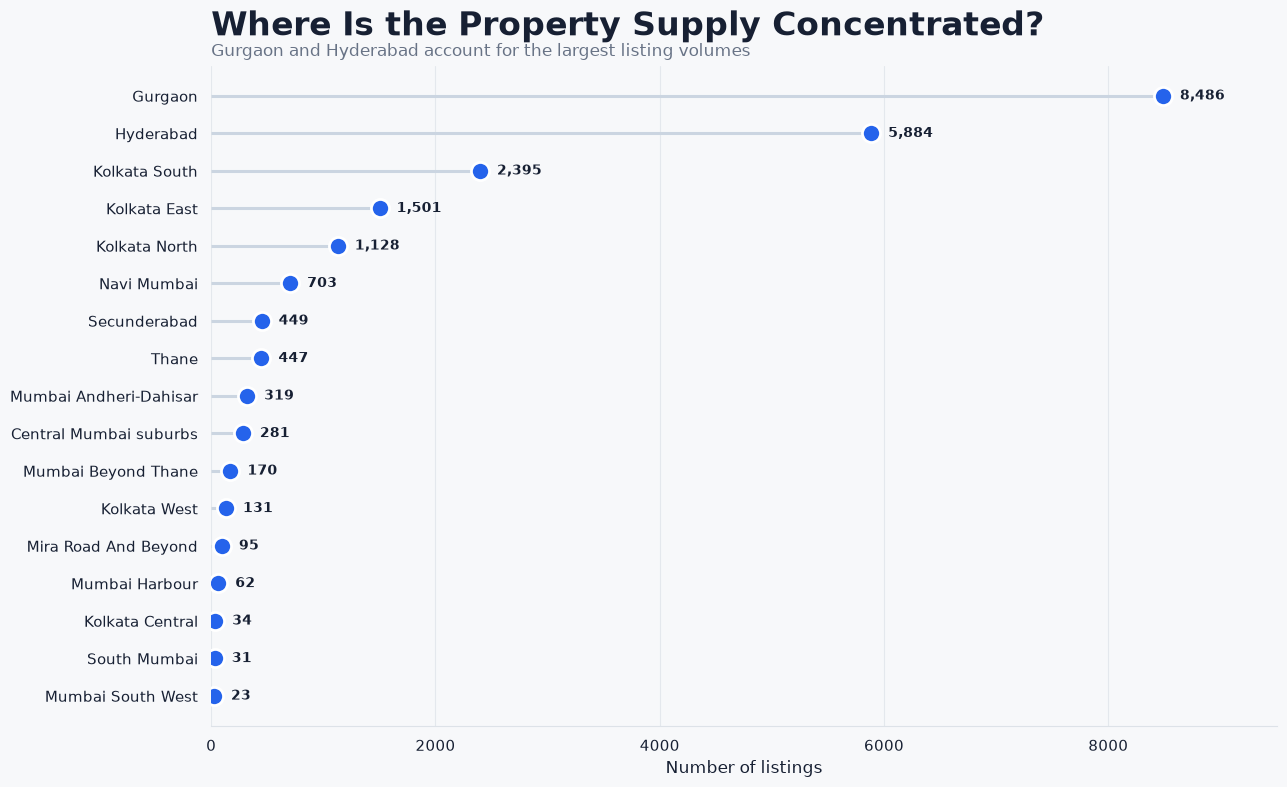

In [156]:
# Market Supply by City

city_counts = (
    analysis_model
    .groupby("CITY")
    .size()
    .sort_values(ascending=True)
)

fig, ax = plt.subplots(figsize=(13, 8))

y = np.arange(len(city_counts))

ax.hlines(
    y=y,
    xmin=0,
    xmax=city_counts.values,
    color="#CBD5E1",
    linewidth=2.2
)

ax.scatter(
    city_counts.values,
    y,
    s=170,
    color=BLUE,
    edgecolor="white",
    linewidth=2,
    zorder=3
)

for i, value in enumerate(city_counts.values):
    ax.text(
        value + city_counts.max() * 0.018,
        i,
        f"{value:,}",
        va="center",
        fontsize=10,
        fontweight="bold",
        color=TEXT
    )

ax.set_yticks(y)
ax.set_yticklabels(city_counts.index)

ax.set_xlim(0, city_counts.max() * 1.12)

ax.set_title(
    "Where Is the Property Supply Concentrated?",
    fontsize=24,
    loc="left",
    pad=22
)

ax.text(
    0,
    1.015,
    "Gurgaon and Hyderabad account for the largest listing volumes",
    transform=ax.transAxes,
    fontsize=12,
    color=MUTED
)

ax.set_xlabel("Number of listings", fontsize=12)

ax.grid(
    axis="x",
    color=GRID,
    linewidth=0.8,
    alpha=0.7
)

ax.grid(
    axis="y",
    visible=False
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

plt.tight_layout()

plt.savefig(
    charts_dir / "01_market_supply_by_city.png",
    dpi=320,
    bbox_inches="tight"
)

plt.show()

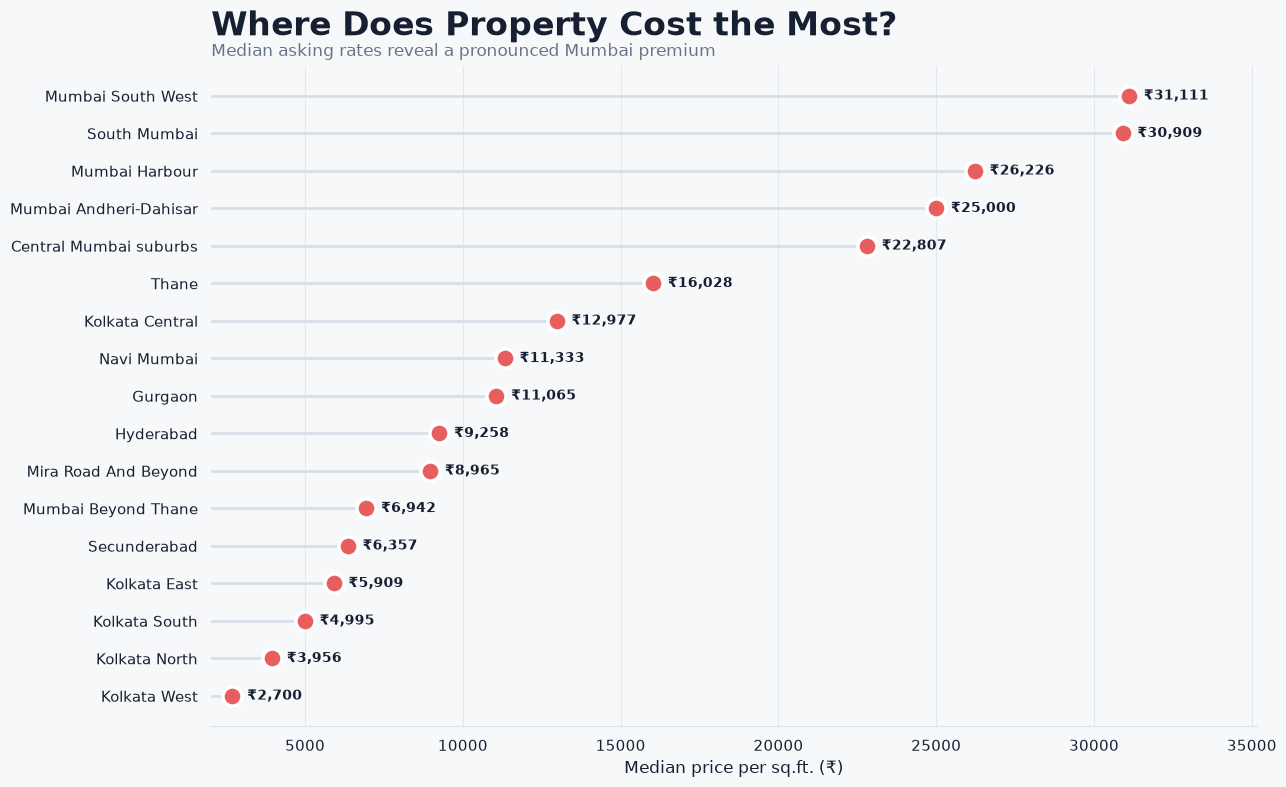

In [157]:
# Median Price by City

city_price = (
    analysis_model
    .groupby("CITY")["PRICE_SQFT"]
    .median()
    .sort_values()
)

fig, ax = plt.subplots(figsize=(13, 8))

y = np.arange(len(city_price))

ax.hlines(
    y,
    0,
    city_price.values,
    color="#D8DEE7",
    linewidth=2
)

ax.scatter(
    city_price.values,
    y,
    s=190,
    color=CORAL,
    edgecolor="white",
    linewidth=2.5,
    zorder=3
)

for i, value in enumerate(city_price.values):
    ax.text(
        value + city_price.max() * 0.015,
        i,
        f"₹{value:,.0f}",
        va="center",
        fontsize=10,
        fontweight="bold"
    )

ax.set_yticks(y)
ax.set_yticklabels(city_price.index)

ax.set_xlim(
    max(0, city_price.min() * 0.75),
    city_price.max() * 1.13
)

ax.set_title(
    "Where Does Property Cost the Most?",
    fontsize=24,
    loc="left",
    pad=22
)

ax.text(
    0,
    1.015,
    "Median asking rates reveal a pronounced Mumbai premium",
    transform=ax.transAxes,
    fontsize=12,
    color=MUTED
)

ax.set_xlabel("Median price per sq.ft. (₹)", fontsize=12)

ax.grid(
    axis="x",
    color=GRID,
    linewidth=0.8,
    alpha=0.7
)

ax.grid(
    axis="y",
    visible=False
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

plt.tight_layout()

plt.savefig(
    charts_dir / "02_median_price_by_city.png",
    dpi=320,
    bbox_inches="tight"
)

plt.show()

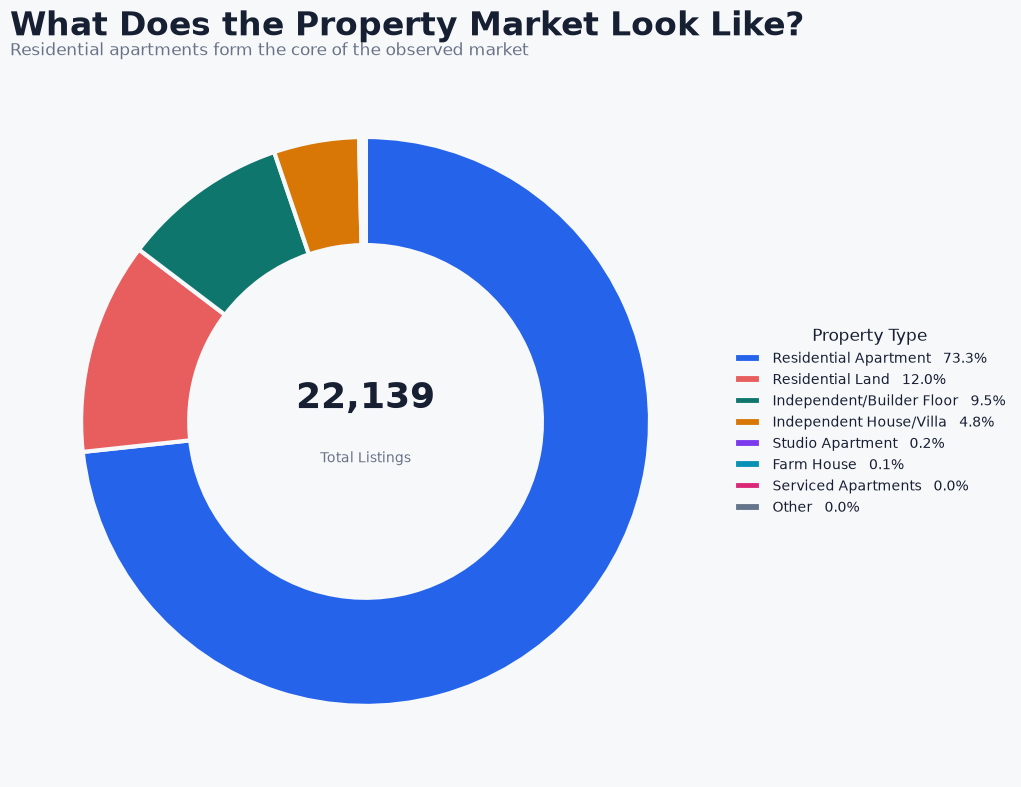

In [158]:
# Property Market Composition

type_counts = (
    analysis_model["PROPERTY_TYPE"]
    .value_counts()
)

fig, ax = plt.subplots(figsize=(11, 8))

colors = [
    BLUE,
    CORAL,
    TEAL,
    AMBER,
    PURPLE,
    CYAN,
    PINK,
    "#64748B"
]

wedges, _ = ax.pie(
    type_counts.values,
    startangle=90,
    counterclock=False,
    colors=colors[:len(type_counts)],
    wedgeprops={
        "width": 0.38,
        "edgecolor": BG,
        "linewidth": 3
    }
)

total = type_counts.sum()

ax.text(
    0,
    0.08,
    f"{total:,}",
    ha="center",
    va="center",
    fontsize=26,
    fontweight="bold"
)

ax.text(
    0,
    -0.13,
    "Total Listings",
    ha="center",
    va="center",
    fontsize=10,
    color=MUTED
)

legend_labels = [
    f"{name}   {value / total:.1%}"
    for name, value in type_counts.items()
]

ax.legend(
    wedges,
    legend_labels,
    title="Property Type",
    loc="center left",
    bbox_to_anchor=(1.0, 0.5),
    frameon=False,
    fontsize=10
)

ax.set_title(
    "What Does the Property Market Look Like?",
    fontsize=24,
    loc="left",
    pad=22
)

ax.text(
    0,
    1.015,
    "Residential apartments form the core of the observed market",
    transform=ax.transAxes,
    fontsize=12,
    color=MUTED
)

plt.tight_layout()

plt.savefig(
    charts_dir / "03_property_market_composition.png",
    dpi=320,
    bbox_inches="tight"
)

plt.show()

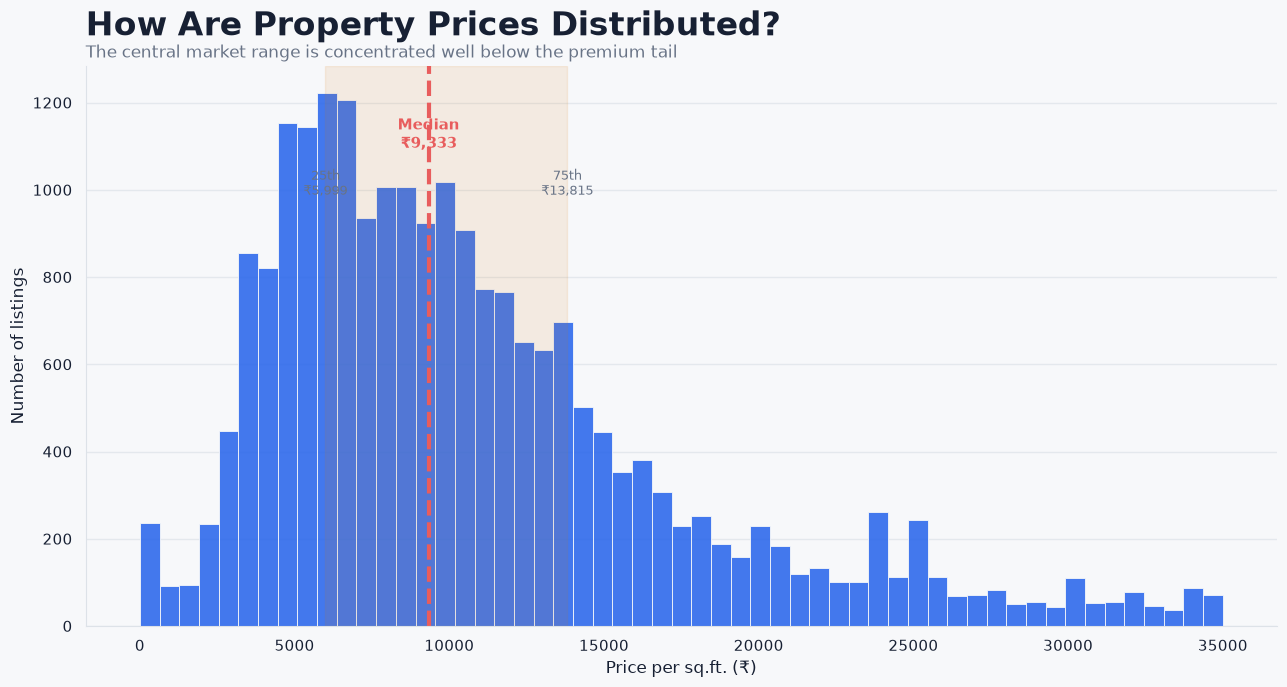

In [159]:
# Property Price Distribution

price = (
    analysis_model["PRICE_SQFT"]
    .dropna()
)

q25, median, q75 = price.quantile([0.25, 0.50, 0.75])

fig, ax = plt.subplots(figsize=(13, 7))

ax.hist(
    price,
    bins=55,
    color=BLUE,
    alpha=0.86,
    edgecolor=BG,
    linewidth=0.7
)

ax.axvspan(
    q25,
    q75,
    color=AMBER,
    alpha=0.10
)

ax.axvline(
    median,
    color=CORAL,
    linewidth=3,
    linestyle="--"
)

ax.text(
    median,
    ax.get_ylim()[1] * 0.91,
    f"Median\n₹{median:,.0f}",
    ha="center",
    va="top",
    fontsize=11,
    fontweight="bold",
    color=CORAL
)

ax.text(
    q25,
    ax.get_ylim()[1] * 0.77,
    f"25th\n₹{q25:,.0f}",
    ha="center",
    fontsize=9,
    color=MUTED
)

ax.text(
    q75,
    ax.get_ylim()[1] * 0.77,
    f"75th\n₹{q75:,.0f}",
    ha="center",
    fontsize=9,
    color=MUTED
)

ax.set_title(
    "How Are Property Prices Distributed?",
    fontsize=24,
    loc="left",
    pad=22
)

ax.text(
    0,
    1.015,
    "The central market range is concentrated well below the premium tail",
    transform=ax.transAxes,
    fontsize=12,
    color=MUTED
)

ax.set_xlabel("Price per sq.ft. (₹)", fontsize=12)
ax.set_ylabel("Number of listings", fontsize=12)

ax.grid(
    axis="y",
    color=GRID,
    alpha=0.7
)

ax.grid(
    axis="x",
    visible=False
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

plt.savefig(
    charts_dir / "04_price_distribution.png",
    dpi=320,
    bbox_inches="tight"
)

plt.show()

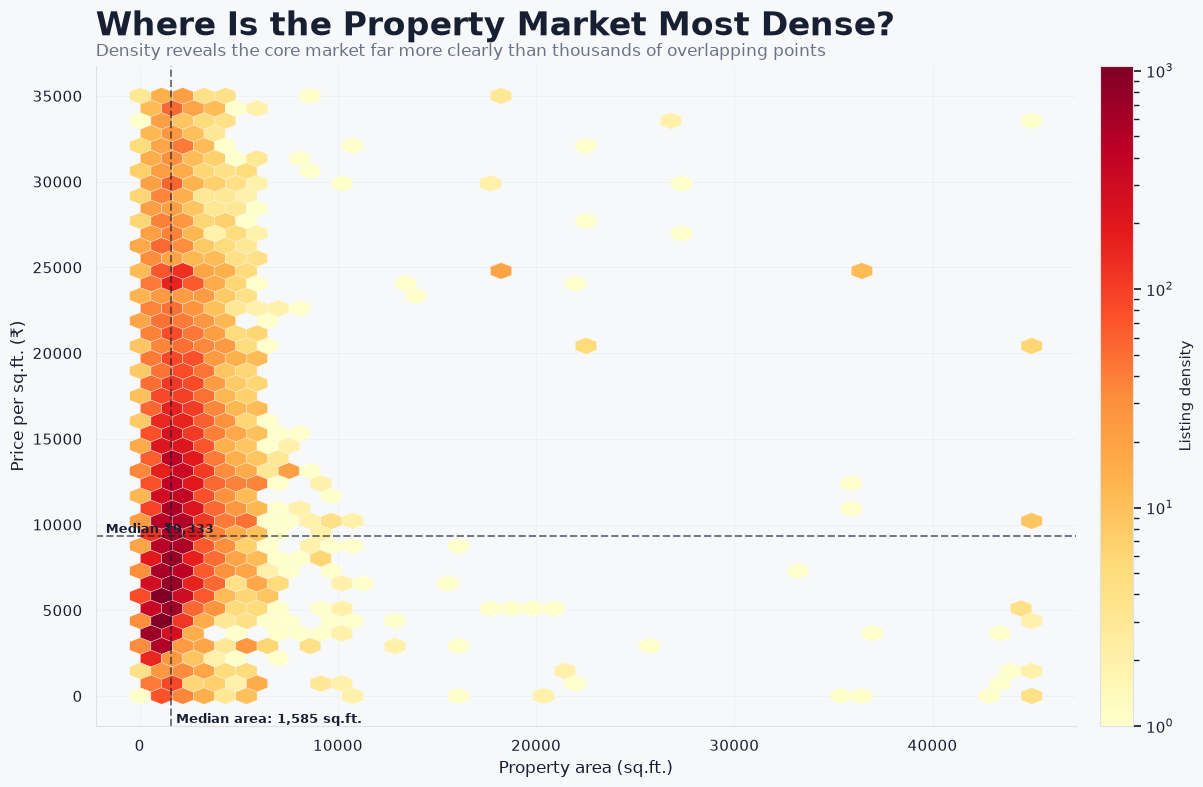

In [160]:
# Area and Price Density

plot_data = (
    analysis_model[
        ["AREA", "PRICE_SQFT"]
    ]
    .dropna()
)

x = plot_data["AREA"]
y = plot_data["PRICE_SQFT"]

fig, ax = plt.subplots(figsize=(13, 8))

hb = ax.hexbin(
    x,
    y,
    gridsize=42,
    mincnt=1,
    cmap="YlOrRd",
    bins="log",
    linewidths=0.25,
    edgecolors=BG
)

median_area = x.median()
median_price = y.median()

ax.axvline(
    median_area,
    color=TEXT,
    linestyle="--",
    linewidth=1.4,
    alpha=0.6
)

ax.axhline(
    median_price,
    color=TEXT,
    linestyle="--",
    linewidth=1.4,
    alpha=0.6
)

ax.text(
    median_area,
    ax.get_ylim()[0],
    f" Median area: {median_area:,.0f} sq.ft.",
    va="bottom",
    fontsize=9,
    fontweight="bold"
)

ax.text(
    ax.get_xlim()[0],
    median_price,
    f"  Median ₹{median_price:,.0f}",
    va="bottom",
    fontsize=9,
    fontweight="bold"
)

colorbar = fig.colorbar(
    hb,
    ax=ax,
    pad=0.02
)

colorbar.set_label(
    "Listing density",
    fontsize=11
)

ax.set_title(
    "Where Is the Property Market Most Dense?",
    fontsize=24,
    loc="left",
    pad=22
)

ax.text(
    0,
    1.015,
    "Density reveals the core market far more clearly than thousands of overlapping points",
    transform=ax.transAxes,
    fontsize=12,
    color=MUTED
)

ax.set_xlabel("Property area (sq.ft.)", fontsize=12)
ax.set_ylabel("Price per sq.ft. (₹)", fontsize=12)

ax.grid(
    color=GRID,
    alpha=0.35,
    linewidth=0.7
)

ax.set_axisbelow(True)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

plt.savefig(
    charts_dir / "05_area_price_density.png",
    dpi=320,
    bbox_inches="tight"
)

plt.show()

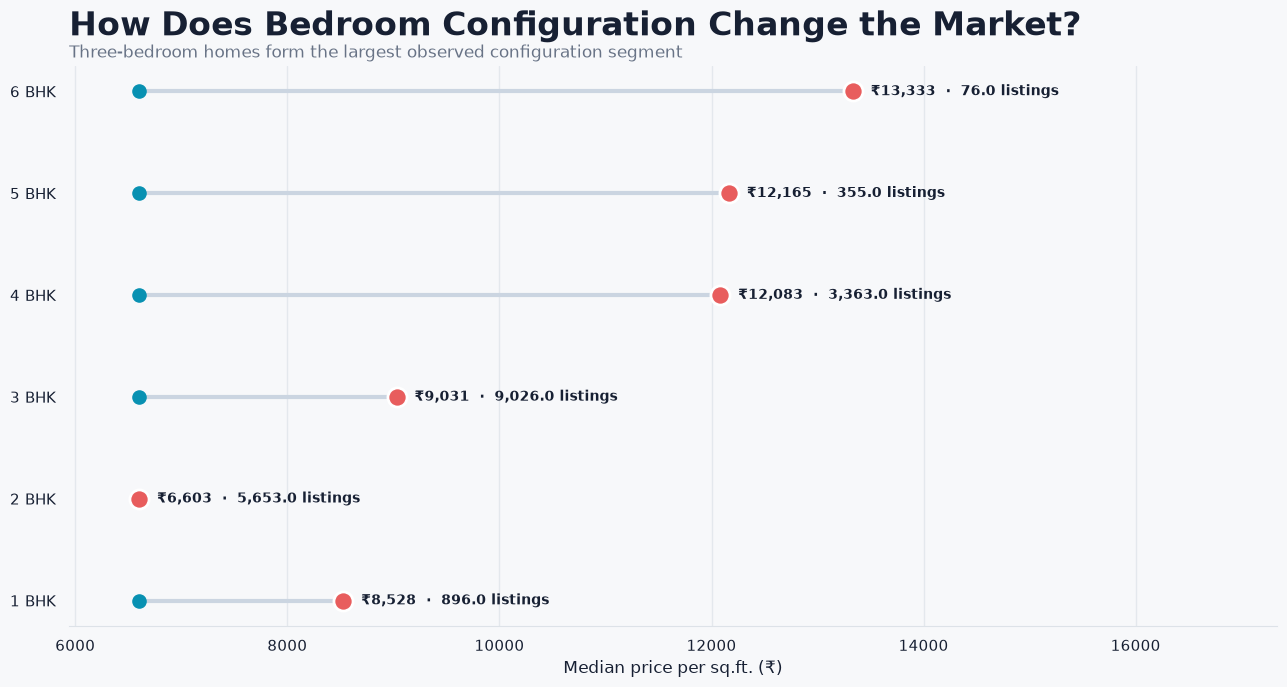

In [161]:
# Bedroom Market Comparison

bhk = (
    analysis_model[
        analysis_model["BEDROOM_NUM"].notna()
    ]
    .loc[lambda d: d["BEDROOM_NUM"] <= 6]
    .groupby("BEDROOM_NUM")
    .agg(
        listings=("BEDROOM_NUM", "size"),
        median_price=("PRICE_SQFT", "median")
    )
    .reset_index()
    .sort_values("BEDROOM_NUM")
)

fig, ax = plt.subplots(figsize=(13, 7))

price_min = bhk["median_price"].min()
price_max = bhk["median_price"].max()

ax.hlines(
    bhk["BEDROOM_NUM"],
    price_min,
    bhk["median_price"],
    color="#CBD5E1",
    linewidth=3
)

ax.scatter(
    [price_min] * len(bhk),
    bhk["BEDROOM_NUM"],
    s=90,
    color=CYAN,
    zorder=3,
    label="Lower observed median"
)

ax.scatter(
    bhk["median_price"],
    bhk["BEDROOM_NUM"],
    s=190,
    color=CORAL,
    edgecolor="white",
    linewidth=2,
    zorder=4,
    label="Median price"
)

for _, row in bhk.iterrows():

    ax.text(
        row["median_price"] + (price_max - price_min) * 0.025,
        row["BEDROOM_NUM"],
        f"₹{row['median_price']:,.0f}  ·  {row['listings']:,} listings",
        va="center",
        fontsize=10,
        fontweight="bold"
    )

ax.set_yticks(bhk["BEDROOM_NUM"])
ax.set_yticklabels(
    [f"{int(x)} BHK" for x in bhk["BEDROOM_NUM"]]
)

ax.set_xlim(
    price_min * 0.90,
    price_max * 1.30
)

ax.set_title(
    "How Does Bedroom Configuration Change the Market?",
    fontsize=24,
    loc="left",
    pad=22
)

ax.text(
    0,
    1.015,
    "Three-bedroom homes form the largest observed configuration segment",
    transform=ax.transAxes,
    fontsize=12,
    color=MUTED
)

ax.set_xlabel(
    "Median price per sq.ft. (₹)",
    fontsize=12
)

ax.grid(
    axis="x",
    color=GRID,
    alpha=0.7
)

ax.grid(
    axis="y",
    visible=False
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

plt.tight_layout()

plt.savefig(
    charts_dir / "06_bedroom_market_comparison.png",
    dpi=320,
    bbox_inches="tight"
)

plt.show()

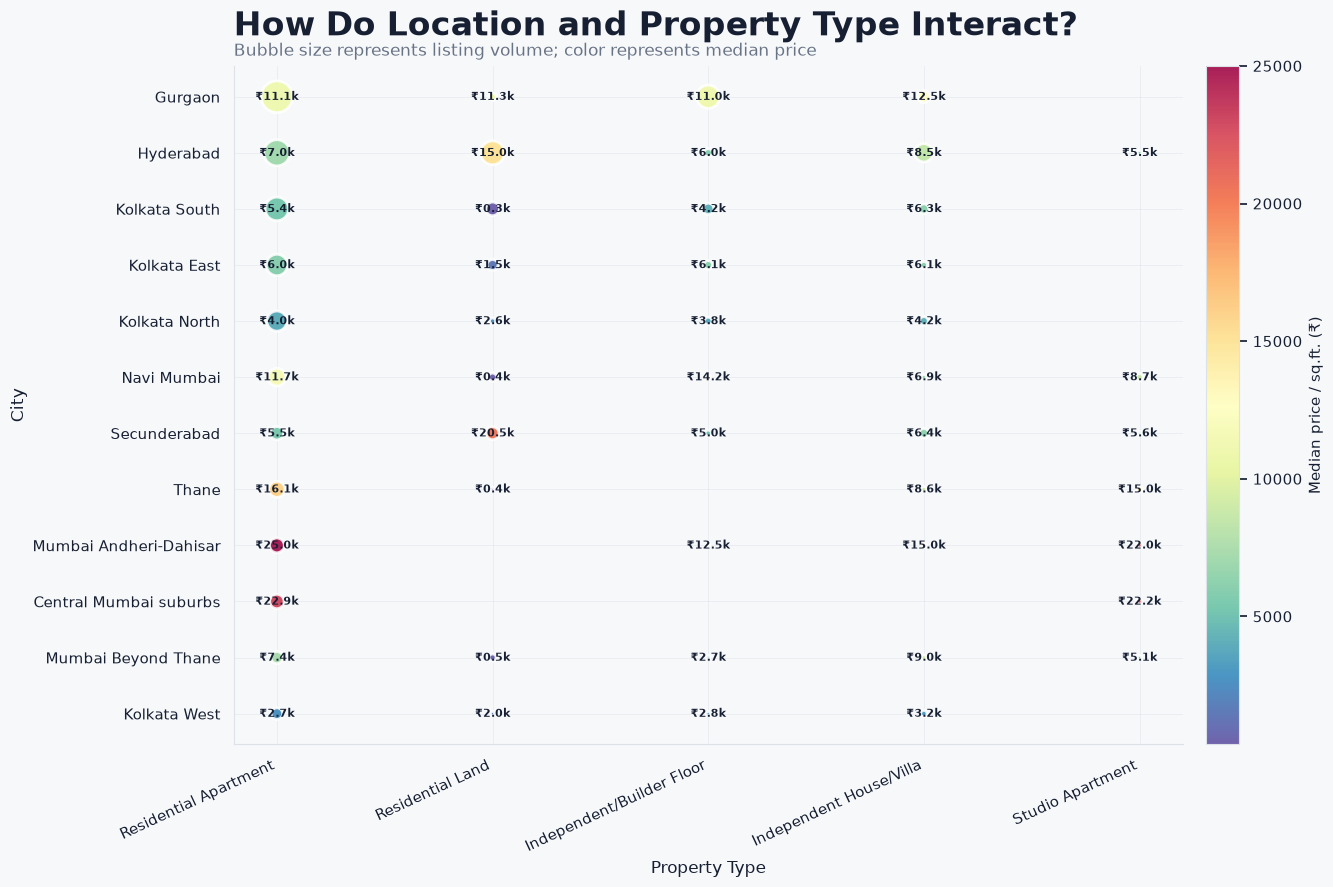

In [162]:
# City and Property Type Market Matrix

market = (
    analysis_model
    .groupby(["CITY", "PROPERTY_TYPE"])
    .agg(
        median_price=("PRICE_SQFT", "median"),
        listings=("PRICE_SQFT", "size")
    )
    .reset_index()
)

top_cities = (
    analysis_model["CITY"]
    .value_counts()
    .head(12)
    .index
)

top_types = (
    analysis_model["PROPERTY_TYPE"]
    .value_counts()
    .head(5)
    .index
)

market = market[
    market["CITY"].isin(top_cities)
    & market["PROPERTY_TYPE"].isin(top_types)
]

cities = list(top_cities)
types = list(top_types)

market["city_pos"] = market["CITY"].map(
    {city: i for i, city in enumerate(cities)}
)

market["type_pos"] = market["PROPERTY_TYPE"].map(
    {ptype: i for i, ptype in enumerate(types)}
)

fig, ax = plt.subplots(figsize=(14, 9))

size_scale = 520 / np.sqrt(
    max(market["listings"].max(), 1)
)

scatter = ax.scatter(
    market["type_pos"],
    market["city_pos"],
    s=np.sqrt(market["listings"]) * size_scale,
    c=market["median_price"],
    cmap="Spectral_r",
    alpha=0.88,
    edgecolor="white",
    linewidth=2
)

for _, row in market.iterrows():

    ax.text(
        row["type_pos"],
        row["city_pos"],
        f"₹{row['median_price']/1000:.1f}k",
        ha="center",
        va="center",
        fontsize=8,
        fontweight="bold",
        color=TEXT
    )

ax.set_xticks(range(len(types)))
ax.set_xticklabels(
    types,
    rotation=25,
    ha="right"
)

ax.set_yticks(range(len(cities)))
ax.set_yticklabels(cities)

ax.invert_yaxis()

ax.set_title(
    "How Do Location and Property Type Interact?",
    fontsize=24,
    loc="left",
    pad=22
)

ax.text(
    0,
    1.015,
    "Bubble size represents listing volume; color represents median price",
    transform=ax.transAxes,
    fontsize=12,
    color=MUTED
)

ax.set_xlabel("Property Type", fontsize=12)
ax.set_ylabel("City", fontsize=12)

colorbar = fig.colorbar(
    scatter,
    ax=ax,
    pad=0.02
)

colorbar.set_label(
    "Median price / sq.ft. (₹)",
    fontsize=11
)

ax.grid(
    color=GRID,
    alpha=0.5,
    linewidth=0.7
)

ax.set_axisbelow(True)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

plt.savefig(
    charts_dir / "07_city_property_type_matrix.png",
    dpi=320,
    bbox_inches="tight"
)

plt.show()

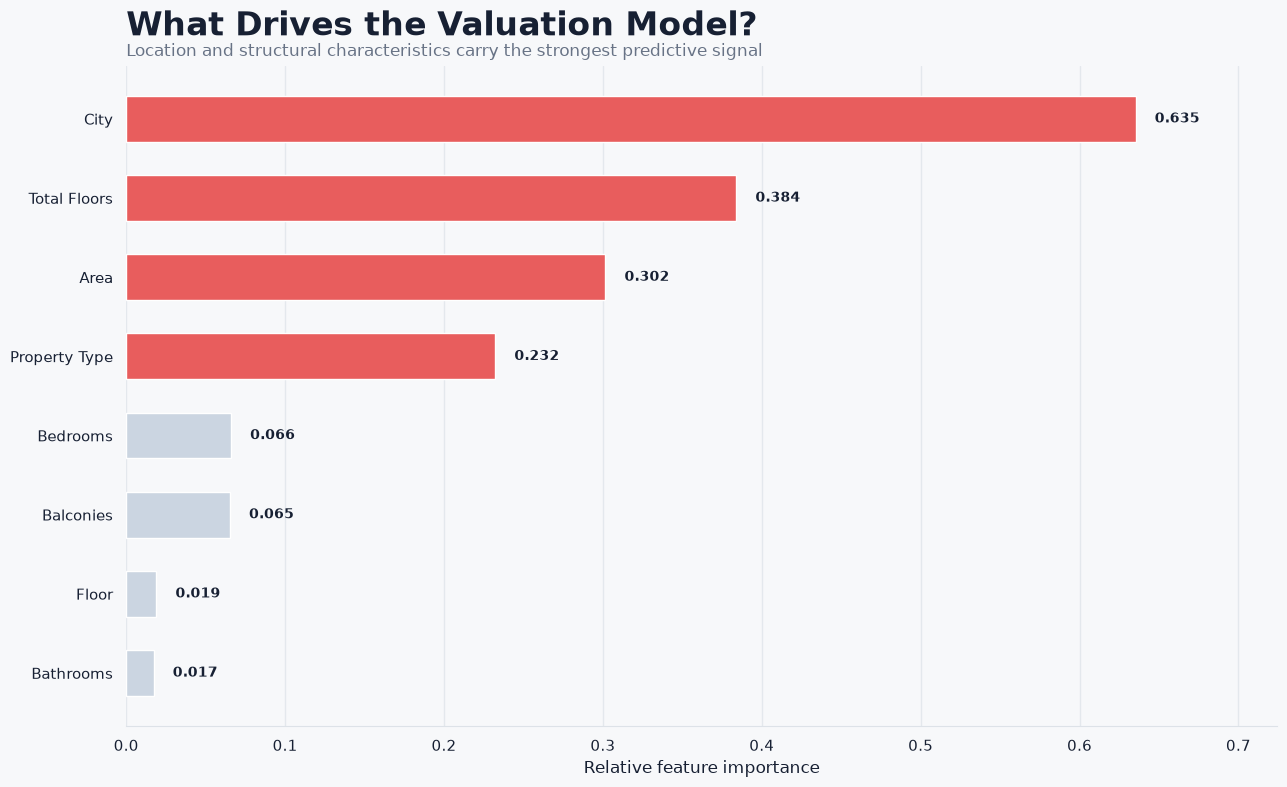

In [163]:
# Model Feature Importance

feature_importance = pd.DataFrame({
    "Feature": [
        "City",
        "Total Floors",
        "Area",
        "Property Type",
        "Bedrooms",
        "Balconies",
        "Floor",
        "Bathrooms"
    ],
    "Importance": [
        0.6353,
        0.3840,
        0.3016,
        0.2323,
        0.0660,
        0.0653,
        0.0190,
        0.0173
    ]
}).sort_values("Importance")

fig, ax = plt.subplots(figsize=(13, 8))

values = feature_importance["Importance"]
labels = feature_importance["Feature"]

colors = [
    CORAL if value >= 0.20 else "#CBD5E1"
    for value in values
]

bars = ax.barh(
    labels,
    values,
    color=colors,
    height=0.58
)

for bar, value in zip(bars, values):

    ax.text(
        value + 0.012,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.3f}",
        va="center",
        fontsize=10,
        fontweight="bold"
    )

ax.set_xlim(
    0,
    values.max() * 1.14
)

ax.set_title(
    "What Drives the Valuation Model?",
    fontsize=24,
    loc="left",
    pad=22
)

ax.text(
    0,
    1.015,
    "Location and structural characteristics carry the strongest predictive signal",
    transform=ax.transAxes,
    fontsize=12,
    color=MUTED
)

ax.set_xlabel(
    "Relative feature importance",
    fontsize=12
)

ax.grid(
    axis="x",
    color=GRID,
    alpha=0.7
)

ax.grid(
    axis="y",
    visible=False
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

plt.tight_layout()

plt.savefig(
    charts_dir / "08_model_feature_importance.png",
    dpi=320,
    bbox_inches="tight"
)

plt.show()

In [61]:
# Location-Level Opportunity Analysis

location_df = analysis_model.copy()

# Select the most useful available location field
location_df["LOCATION_NAME"] = (
    location_df["SOCIETY_NAME"]
    .fillna(location_df["BUILDING_NAME"])
    .fillna("Unknown")
    .astype(str)
    .str.strip()
)

# Remove unusable location names
location_df = location_df[
    ~location_df["LOCATION_NAME"].isin(
        ["", "Unknown", "nan", "None"]
    )
].copy()

# Keep valid price observations
location_df = location_df.dropna(
    subset=["PRICE_SQFT"]
).copy()

# Build location-level summary
location_summary = (
    location_df
    .groupby(
        ["CITY", "LOCATION_NAME"],
        observed=True
    )
    .agg(
        Properties=("PROP_ID", "count"),
        Median_Price_SqFt=("PRICE_SQFT", "median"),
        Average_Price_SqFt=("PRICE_SQFT", "mean")
    )
    .reset_index()
)

# Ignore locations with very little evidence
location_summary = location_summary[
    location_summary["Properties"] >= 10
].copy()

# Activity score
location_summary["Activity_Score"] = (
    location_summary["Properties"] /
    location_summary["Properties"].max()
) * 100

# Relative pricing score
location_summary["Price_Score"] = (
    location_summary["Median_Price_SqFt"] /
    location_summary["Median_Price_SqFt"].median()
) * 50

# Combined opportunity score
location_summary["Opportunity_Score"] = (
    location_summary["Activity_Score"] * 0.65
    + location_summary["Price_Score"] * 0.35
)

# Rank locations
location_ranking = (
    location_summary
    .sort_values(
        "Opportunity_Score",
        ascending=False
    )
    .reset_index(drop=True)
)

location_ranking["Rank"] = (
    location_ranking.index + 1
)

location_ranking = location_ranking[
    [
        "Rank",
        "CITY",
        "LOCATION_NAME",
        "Properties",
        "Median_Price_SqFt",
        "Average_Price_SqFt",
        "Activity_Score",
        "Price_Score",
        "Opportunity_Score"
    ]
]

location_ranking.head(20)


,Rank,CITY,LOCATION_NAME,Properties,Median_Price_SqFt,Average_Price_SqFt,Activity_Score,Price_Score,Opportunity_Score
0,1,Gurgaon,Emaar Digihomes,111,16416.0,17090.936937,84.090909,87.089843,85.140536
1,2,Gurgaon,DLF The Crest,46,32540.5,31487.434783,34.848485,172.633226,83.073144
2,3,Gurgaon,Sobha City,89,17378.0,17576.123596,67.424242,92.193427,76.093457
3,4,Gurgaon,Puri The Aravallis,37,30408.0,25704.297297,28.030303,161.319929,74.681672
4,5,Kolkata South,On Request,132,4841.5,5920.250000,100.000000,25.685031,73.989761
5,6,Gurgaon,Central Park Resorts,45,27085.0,25960.044444,34.090909,143.690814,72.450876
6,7,Gurgaon,DLF Park Place,52,25214.0,25203.826923,39.393939,133.764821,72.423748
7,8,Gurgaon,Conscient Elevate,76,18566.5,18805.934211,57.575758,98.498634,71.898764
8,9,Hyderabad,Srika Green Oasis,24,32000.0,31709.583333,18.181818,169.765776,71.236204
9,10,Hyderabad,Prestige High Fields,99,11500.0,12761.121212,75.000000,61.009576,70.103352


## Business Insights & Final Conclusions

In [62]:
# Generate the final analytical insight summary

top_markets = market_df.sort_values(
    "Opportunity_Score",
    ascending=False
).reset_index(drop=True)

top_locations = location_ranking.sort_values(
    "Opportunity_Score",
    ascending=False
).reset_index(drop=True)

# Market-level insights
print("EstateIQ — Key Market Insights")
print()

leader = top_markets.iloc[0]
second = top_markets.iloc[1]

print(
    f"1. {leader['CITY']} ranks as the strongest overall market "
    f"with an Opportunity Score of {leader['Opportunity_Score']:.2f}."
)

print(
    f"2. {second['CITY']} follows with an Opportunity Score "
    f"of {second['Opportunity_Score']:.2f}."
)

premium_markets = top_markets[
    top_markets["Market_Position"] == "Premium Niche Market"
]

if len(premium_markets) > 0:
    highest_premium = premium_markets.iloc[0]

    print(
        f"3. {highest_premium['CITY']} leads the Premium Niche segment "
        f"with a median price of "
        f"₹{highest_premium['Median_Price_SqFt']:,.0f}/sq.ft."
    )

active_markets = top_markets[
    top_markets["Market_Position"] == "High-Activity Mid-Market"
]

if len(active_markets) > 0:
    highest_activity_mid = active_markets.iloc[0]

    print(
        f"4. {highest_activity_mid['CITY']} represents the strongest "
        f"High-Activity Mid-Market opportunity."
    )

emerging_markets = top_markets[
    top_markets["Market_Position"] == "Emerging / Value Market"
]

if len(emerging_markets) > 0:
    strongest_emerging = emerging_markets.iloc[0]

    print(
        f"5. {strongest_emerging['CITY']} leads the Emerging / Value "
        f"Market group with an Opportunity Score of "
        f"{strongest_emerging['Opportunity_Score']:.2f}."
    )


# Location-level insights
print()
print("Top Location-Level Opportunities")
print()

for _, row in top_locations.head(10).iterrows():

    location_name = str(row["LOCATION_NAME"])

    print(
        f"{int(row['Rank']):02d}. "
        f"{row['CITY']} — {location_name} | "
        f"{int(row['Properties']):,} properties | "
        f"₹{row['Median_Price_SqFt']:,.0f}/sq.ft. | "
        f"Opportunity {row['Opportunity_Score']:.1f}"
    )


EstateIQ — Key Market Insights

1. Gurgaon ranks as the strongest overall market with an Opportunity Score of 74.23.
2. Hyderabad follows with an Opportunity Score of 53.51.
3. Mumbai Andheri-Dahisar leads the Premium Niche segment with a median price of ₹25,000/sq.ft.
4. Kolkata South represents the strongest High-Activity Mid-Market opportunity.
5. Mira Road And Beyond leads the Emerging / Value Market group with an Opportunity Score of 12.20.

Top Location-Level Opportunities

01. Gurgaon — Emaar Digihomes | 111 properties | ₹16,416/sq.ft. | Opportunity 85.1
02. Gurgaon — DLF The Crest | 46 properties | ₹32,540/sq.ft. | Opportunity 83.1
03. Gurgaon — Sobha City | 89 properties | ₹17,378/sq.ft. | Opportunity 76.1
04. Gurgaon — Puri The Aravallis | 37 properties | ₹30,408/sq.ft. | Opportunity 74.7
05. Kolkata South — On Request | 132 properties | ₹4,842/sq.ft. | Opportunity 74.0
06. Gurgaon — Central Park Resorts | 45 properties | ₹27,085/sq.ft. | Opportunity 72.5
07. Gurgaon — DLF Pa

In [83]:
# Prepare AREA for reliable numerical analysis

analysis_model["AREA_NUMERIC"] = (
    analysis_model["AREA"]
    .astype(str)
    .str.replace(",", "", regex=False)
    .str.extract(r"([\d.]+)", expand=False)
)

analysis_model["AREA_NUMERIC"] = pd.to_numeric(
    analysis_model["AREA_NUMERIC"],
    errors="coerce"
)

area_by_type = (
    analysis_model
    .groupby("PROPERTY_TYPE")["AREA_NUMERIC"]
    .agg(
        records="count",
        median="median",
        q95=lambda x: x.quantile(0.95),
        q99=lambda x: x.quantile(0.99),
        maximum="max"
    )
    .sort_values("maximum", ascending=False)
)

area_by_type.round(0)

,records,median,q95,q99,maximum
PROPERTY_TYPE,,,,,
Residential Land,2665,1647.0,6534.0,45000.0,7649100
Residential Apartment,16226,1480.0,3495.0,5800.0,2994000
Farm House,26,5445.0,13140.0,33300.0,39600
Independent House/Villa,1071,2780.0,7400.0,10296.0,30222
Independent/Builder Floor,2096,1926.0,4500.0,5460.0,24300
Other,1,6534.0,6534.0,6534.0,6534
Serviced Apartments,5,1795.0,3961.0,4392.0,4500
Studio Apartment,49,306.0,450.0,616.0,750


In [84]:
# Inspect unusually large property areas

large_area_properties = (
    analysis_model[
        analysis_model["AREA_NUMERIC"] > 10000
    ][
        [
            "PROP_ID",
            "CITY",
            "PROPERTY_TYPE",
            "AREA",
            "AREA_NUMERIC",
            "PRICE_SQFT"
        ]
    ]
    .sort_values(
        "AREA_NUMERIC",
        ascending=False
    )
)

print(
    f"Properties above 10,000 sq.ft.: "
    f"{len(large_area_properties):,}"
)

large_area_properties.head(30)

Properties above 10,000 sq.ft.: 168


,PROP_ID,CITY,PROPERTY_TYPE,AREA,AREA_NUMERIC,PRICE_SQFT
14645,M70261390,Hyderabad,Residential Land,7649100 sq.ft.,7649100,1.0
19606,Z71202744,Kolkata East,Residential Apartment,2994000 sq.ft.,2994000,1.0
11035,T70992072,Hyderabad,Residential Land,1900000 sq.ft.,1900000,1.0
7719,A71163604,Gurgaon,Residential Apartment,577946 sq.ft.,577946,7.0
2762,H71724982,Gurgaon,Residential Apartment,569243 sq.ft.,569243,6.0
2763,V71724980,Gurgaon,Residential Apartment,569243 sq.ft.,569243,7.0
7714,Q71590308,Gurgaon,Residential Apartment,553856 sq.ft.,553856,7.0
16159,Z38453097,Kolkata South,Residential Land,519119 sq.ft.,519119,346.0
2764,K71724976,Gurgaon,Residential Apartment,514272 sq.ft.,514272,7.0
1401,T71724970,Gurgaon,Residential Apartment,514272 sq.ft.,514272,7.0


In [85]:
# Final AREA cleaning for the processed analytical dataset

import numpy as np
import pandas as pd

# Preserve the original AREA temporarily for validation
area_original = analysis_model["AREA"].copy()

# Convert AREA to numeric
analysis_model["AREA"] = (
    analysis_model["AREA"]
    .astype(str)
    .str.replace(",", "", regex=False)
    .str.extract(r"([\d.]+)", expand=False)
)

analysis_model["AREA"] = pd.to_numeric(
    analysis_model["AREA"],
    errors="coerce"
)

# Basic validity check
invalid_area_mask = (
    analysis_model["AREA"].isna()
    | (analysis_model["AREA"] <= 0)
)

analysis_model.loc[invalid_area_mask, "AREA"] = np.nan

# Calculate property-type-specific 99th percentile limits
area_limits = (
    analysis_model
    .groupby("PROPERTY_TYPE")["AREA"]
    .quantile(0.99)
)

# Apply the 99th percentile cap within each property type
outlier_count = 0

for property_type, upper_limit in area_limits.items():

    mask = (
        analysis_model["PROPERTY_TYPE"].eq(property_type)
        & analysis_model["AREA"].notna()
        & (analysis_model["AREA"] > upper_limit)
    )

    outlier_count += mask.sum()

    analysis_model.loc[mask, "AREA"] = upper_limit

# Ensure AREA is numeric and rounded
analysis_model["AREA"] = (
    analysis_model["AREA"]
    .round()
    .astype("Int64")
)

print("AREA cleaning completed")
print("-" * 40)
print(f"Records: {len(analysis_model):,}")
print(f"Original valid AREA: {area_original.notna().sum():,}")
print(f"AREA outliers capped: {outlier_count:,}")
print(f"Missing AREA after cleaning: {analysis_model['AREA'].isna().sum():,}")
print(f"Minimum AREA: {analysis_model['AREA'].min():,} sq.ft.")
print(f"Maximum AREA: {analysis_model['AREA'].max():,} sq.ft.")

print("\nFinal AREA distribution by property type:")
print(
    analysis_model
    .groupby("PROPERTY_TYPE")["AREA"]
    .agg(
        records="count",
        median="median",
        maximum="max"
    )
    .round(0)
)

AREA cleaning completed
----------------------------------------
Records: 22,139
Original valid AREA: 22,139
AREA outliers capped: 208
Missing AREA after cleaning: 0
Minimum AREA: 33 sq.ft.
Maximum AREA: 45,000 sq.ft.

Final AREA distribution by property type:
                           records  median  maximum
PROPERTY_TYPE                                      
Farm House                      26  5445.0    33300
Independent House/Villa       1071  2780.0    10296
Independent/Builder Floor     2096  1926.0     5460
Other                            1  6534.0     6534
Residential Apartment        16226  1480.0     5800
Residential Land              2665  1647.0    45000
Serviced Apartments              5  1795.0     4392
Studio Apartment                49   306.0      616


In [86]:
# Verify final AREA quality

print("Final AREA validation")
print("-" * 40)

print(f"Records: {len(analysis_model):,}")
print(f"Valid AREA: {analysis_model['AREA'].notna().sum():,}")
print(f"Missing AREA: {analysis_model['AREA'].isna().sum():,}")
print(f"Minimum AREA: {analysis_model['AREA'].min():,} sq.ft.")
print(f"Maximum AREA: {analysis_model['AREA'].max():,} sq.ft.")

print("\nLargest AREA values:")
print(
    analysis_model[
        ["PROP_ID", "CITY", "PROPERTY_TYPE", "AREA", "PRICE_SQFT"]
    ]
    .sort_values("AREA", ascending=False)
    .head(20)
    .to_string(index=False)
)

Final AREA validation
----------------------------------------
Records: 22,139
Valid AREA: 22,139
Missing AREA: 0
Minimum AREA: 33 sq.ft.
Maximum AREA: 45,000 sq.ft.

Largest AREA values:
  PROP_ID          CITY    PROPERTY_TYPE  AREA  PRICE_SQFT
H70630654     Hyderabad Residential Land 45000     10000.0
V70630644     Hyderabad Residential Land 45000     10000.0
O70630706     Hyderabad Residential Land 45000     20000.0
Y70630668     Hyderabad Residential Land 45000     20000.0
O70502676  Kolkata East Residential Land 45000      4166.0
N70623900     Hyderabad Residential Land 45000     10000.0
A68415964     Hyderabad Residential Land 45000      4648.0
H70623890     Hyderabad Residential Land 45000      1000.0
Z38453097 Kolkata South Residential Land 45000       346.0
M67003692         Thane Residential Land 45000       400.0
S70623924     Hyderabad Residential Land 45000     20000.0
M70261390     Hyderabad Residential Land 45000         1.0
X70598864     Hyderabad Residential Land 4500

## Export Processed Dataset

The cleaned analytical dataset is exported for SQL analysis and downstream project components.

In [87]:
from pathlib import Path

processed_dir = Path("../data/processed")
processed_dir.mkdir(parents=True, exist_ok=True)

processed_path = processed_dir / "estateiq_processed.csv"

analysis_model.to_csv(
    processed_path,
    index=False
)

print("Processed dataset exported successfully")
print(f"Records: {len(analysis_model):,}")
print(f"Columns: {len(analysis_model.columns):,}")
print(f"File: {processed_path.resolve()}")

Processed dataset exported successfully
Records: 22,139
Columns: 24
File: C:\Users\Devendra Upadhyay\OneDrive\Desktop\Estateiq-real-estate-analytics\data\processed\estateiq_processed.csv


# ML Input Data Validation 

In [89]:
# Prepare and validate ML input data

ml_data = analysis_model.copy()

ml_data["AREA"] = (
    ml_data["AREA"]
    .astype(str)
    .str.replace(",", "", regex=False)
    .str.extract(r"([\d]+(?:\.\d+)?)", expand=False)
)

ml_data["AREA"] = pd.to_numeric(
    ml_data["AREA"],
    errors="coerce"
)

area_validation = {
    "records": len(ml_data),
    "missing_area": int(ml_data["AREA"].isna().sum()),
    "invalid_area": int((ml_data["AREA"] <= 0).sum()),
    "minimum_area": int(ml_data["AREA"].min()),
    "maximum_area": int(ml_data["AREA"].max()),
}

print("ML Input Data Validation")
print("----------------------------------------")
print(f"Records: {area_validation['records']:,}")
print(f"Missing AREA: {area_validation['missing_area']:,}")
print(f"Invalid AREA: {area_validation['invalid_area']:,}")
print(f"Minimum AREA: {area_validation['minimum_area']:,} sq.ft.")
print(f"Maximum AREA: {area_validation['maximum_area']:,} sq.ft.")

assert area_validation["missing_area"] == 0
assert area_validation["invalid_area"] == 0
assert area_validation["maximum_area"] <= 45000

print("\nAREA validation passed.")
print("ML will use the cleaned AREA values without additional clipping.")

ML Input Data Validation
----------------------------------------
Records: 22,139
Missing AREA: 0
Invalid AREA: 0
Minimum AREA: 33 sq.ft.
Maximum AREA: 45,000 sq.ft.

AREA validation passed.
ML will use the cleaned AREA values without additional clipping.


# Machine Learning — Property Valuation

The analytical phase of EstateIQ identifies market patterns, pricing differences, and high-opportunity locations.

The next step is to build a predictive valuation model that estimates `PRICE_SQFT` from available property characteristics.

The model uses property attributes such as location, property type, area, bedrooms, bathrooms, balconies, and floor information.

The objective is to evaluate whether these characteristics contain enough information to provide useful automated price-per-square-foot estimates.

The workflow includes:

- Preparing the modelling dataset
- Selecting relevant features
- Handling categorical variables
- Splitting data into training and testing sets
- Establishing a baseline
- Training machine-learning models
- Evaluating prediction accuracy
- Comparing model performance
- Selecting the strongest model


In [90]:
# Prepare the valuation dataset

model_df = analysis_model.copy()

target = "PRICE_SQFT"

feature_candidates = [
    "CITY",
    "PROPERTY_TYPE",
    "BEDROOM_NUM",
    "BATHROOM_NUM",
    "BALCONY_NUM",
    "FLOOR_NUM",
    "TOTAL_FLOOR",
    "AREA"
]

features = [
    col for col in feature_candidates
    if col in model_df.columns
]

model_df = model_df[
    features + [target]
].copy()

# Convert target to numeric
model_df[target] = pd.to_numeric(
    model_df[target],
    errors="coerce"
)

# Keep valid target values only
model_df = model_df[
    model_df[target].notna() &
    (model_df[target] > 0)
].copy()

model_df = (
    model_df
    .drop_duplicates()
    .reset_index(drop=True)
)

print("Valuation dataset prepared")
print("----------------------------------------")
print(f"Records: {len(model_df):,}")
print(f"Features used: {', '.join(features)}")
print(f"Target: {target}")

model_df.head()

Valuation dataset prepared
----------------------------------------
Records: 20,881
Features used: CITY, PROPERTY_TYPE, BEDROOM_NUM, BATHROOM_NUM, BALCONY_NUM, FLOOR_NUM, TOTAL_FLOOR, AREA
Target: PRICE_SQFT


,CITY,PROPERTY_TYPE,BEDROOM_NUM,BATHROOM_NUM,BALCONY_NUM,FLOOR_NUM,TOTAL_FLOOR,AREA,PRICE_SQFT
0,Gurgaon,Residential Apartment,4.0,4.0,4.0,14,26.0,3434,8766.0
1,Gurgaon,Residential Apartment,4.0,4.0,3.0,7,29.0,2870,21176.0
2,Gurgaon,Residential Apartment,3.0,3.0,3.0,14,28.0,2802,13740.0
3,Gurgaon,Residential Apartment,3.0,4.0,4.0,4,27.0,2290,8515.0
4,Gurgaon,Residential Apartment,2.0,2.0,3.0,12,30.0,1400,11571.0


## Prepare Area for Machine Learning

The analytical dataset stores `AREA` as text values such as `3434 sq.ft.`.

For property valuation, the area is converted into a numeric square-foot feature so that the machine-learning models can use it during training.

In [91]:
# Prepare ML dataset

ml_data = analysis_model[
    [
        "CITY",
        "PROPERTY_TYPE",
        "BEDROOM_NUM",
        "BATHROOM_NUM",
        "BALCONY_NUM",
        "FLOOR_NUM",
        "TOTAL_FLOOR",
        "AREA",
        "PRICE_SQFT"
    ]
].copy()

# Convert AREA text such as "3434 sq.ft." into numeric sq.ft.
ml_data["AREA"] = (
    ml_data["AREA"]
    .astype("string")
    .str.replace(",", "", regex=False)
    .str.extract(r"([\d]+(?:\.\d+)?)", expand=False)
)

ml_data["AREA"] = pd.to_numeric(
    ml_data["AREA"],
    errors="coerce"
)

# Convert remaining numerical features
numeric_features = [
    "BEDROOM_NUM",
    "BATHROOM_NUM",
    "BALCONY_NUM",
    "FLOOR_NUM",
    "TOTAL_FLOOR",
    "PRICE_SQFT"
]

for col in numeric_features:
    ml_data[col] = pd.to_numeric(
        ml_data[col],
        errors="coerce"
    )

print("ML dataset prepared")
print("----------------------------------------")
print(f"Records: {len(ml_data):,}")
print(f"Valid AREA values: {ml_data['AREA'].notna().sum():,}")
print(f"Missing AREA values: {ml_data['AREA'].isna().sum():,}")

print("\nAREA statistics:")
print(ml_data["AREA"].describe())

ML dataset prepared
----------------------------------------
Records: 22,139
Valid AREA values: 22,139
Missing AREA values: 0

AREA statistics:
count        22139.0
mean      1961.32174
std      2356.159744
min             33.0
25%           1150.0
50%           1585.0
75%           2200.0
max          45000.0
Name: AREA, dtype: Float64


### AREA Validation for Machine Learning

The `AREA` field was cleaned during the analytical data-preparation stage before the dataset was exported.

The machine-learning stage does not apply additional outlier clipping or capping.

This ensures that the same cleaned `AREA` values are used consistently across SQL analysis, machine learning, and downstream valuation components.

In [92]:
# Final AREA validation before model training

area_validation = {
    "records": len(ml_data),
    "missing_area": int(ml_data["AREA"].isna().sum()),
    "invalid_area": int((ml_data["AREA"] <= 0).sum()),
    "minimum_area": float(ml_data["AREA"].min()),
    "maximum_area": float(ml_data["AREA"].max())
}

print("Final ML AREA Validation")
print("----------------------------------------")
print(f"Records: {area_validation['records']:,}")
print(f"Missing AREA: {area_validation['missing_area']:,}")
print(f"Invalid AREA: {area_validation['invalid_area']:,}")
print(f"Minimum AREA: {area_validation['minimum_area']:,.0f} sq.ft.")
print(f"Maximum AREA: {area_validation['maximum_area']:,.0f} sq.ft.")

assert area_validation["missing_area"] == 0
assert area_validation["invalid_area"] == 0
assert area_validation["maximum_area"] <= 45000

print("\nAREA validation passed.")
print("ML will use the cleaned AREA values without additional clipping.")

Final ML AREA Validation
----------------------------------------
Records: 22,139
Missing AREA: 0
Invalid AREA: 0
Minimum AREA: 33 sq.ft.
Maximum AREA: 45,000 sq.ft.

AREA validation passed.
ML will use the cleaned AREA values without additional clipping.


## Feature Preparation

Categorical variables are converted into numerical representations using one-hot encoding.

Numerical variables are retained as continuous predictors.

Missing numerical values are replaced using the median, while missing categorical values are replaced using the most frequent category.

This preprocessing is placed inside a pipeline so that the same transformations are applied consistently to both training and testing data.


In [93]:
# Prepare features for the valuation model

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

target = "PRICE_SQFT"

# Work from the cleaned ML dataset
model_df = ml_data.copy()

feature_candidates = [
    "CITY",
    "PROPERTY_TYPE",
    "BEDROOM_NUM",
    "BATHROOM_NUM",
    "BALCONY_NUM",
    "FLOOR_NUM",
    "TOTAL_FLOOR",
    "AREA"
]

features = [
    col for col in feature_candidates
    if col in model_df.columns
]

model_df = model_df[
    features + [target]
].copy()

# Remove invalid target values
model_df[target] = pd.to_numeric(
    model_df[target],
    errors="coerce"
)

model_df = model_df[
    model_df[target].notna() &
    (model_df[target] > 0)
].copy()

# Define categorical features
categorical_features = [
    col for col in ["CITY", "PROPERTY_TYPE"]
    if col in features
]

# Define numerical features
numerical_features = [
    col for col in features
    if col not in categorical_features
]

# Force numerical columns to numeric
for col in numerical_features:
    model_df[col] = pd.to_numeric(
        model_df[col],
        errors="coerce"
    )

# Clean categorical columns
for col in categorical_features:
    model_df[col] = (
        model_df[col]
        .astype("string")
        .str.strip()
    )

# Remove duplicate modelling records
model_df = (
    model_df
    .drop_duplicates()
    .reset_index(drop=True)
)

# Numerical preprocessing
numeric_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="median")
    )
])

# Categorical preprocessing
categorical_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="most_frequent")
    ),
    (
        "encoder",
        OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False
        )
    )
])

# Combine preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numeric_pipeline,
            numerical_features
        ),
        (
            "categorical",
            categorical_pipeline,
            categorical_features
        )
    ],
    remainder="drop"
)

# Features and target
X = model_df[features]
y = model_df[target]

# Train / test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("ML dataset prepared successfully")
print("----------------------------------------")
print(f"Records: {len(model_df):,}")
print(f"Features: {', '.join(features)}")
print(f"Categorical: {', '.join(categorical_features)}")
print(f"Numerical: {', '.join(numerical_features)}")
print(f"Training records: {len(X_train):,}")
print(f"Testing records: {len(X_test):,}")

ML dataset prepared successfully
----------------------------------------
Records: 20,879
Features: CITY, PROPERTY_TYPE, BEDROOM_NUM, BATHROOM_NUM, BALCONY_NUM, FLOOR_NUM, TOTAL_FLOOR, AREA
Categorical: CITY, PROPERTY_TYPE
Numerical: BEDROOM_NUM, BATHROOM_NUM, BALCONY_NUM, FLOOR_NUM, TOTAL_FLOOR, AREA
Training records: 16,703
Testing records: 4,176


## Baseline Model

A linear regression model is used as the baseline.

The baseline provides a simple benchmark against which the more flexible Random Forest model can be evaluated.

The main evaluation metrics are:

- **MAE:** average absolute prediction error in ₹/sq.ft.
- **RMSE:** penalizes larger prediction errors more strongly
- **R²:** proportion of variation in price-per-square-foot explained by the model


In [94]:
# Train the baseline valuation model

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

baseline_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

baseline_model.fit(X_train, y_train)

baseline_pred = baseline_model.predict(X_test)

baseline_mae = mean_absolute_error(y_test, baseline_pred)
baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_pred))
baseline_r2 = r2_score(y_test, baseline_pred)

baseline_results = pd.DataFrame({
    "Model": ["Linear Regression"],
    "MAE": [baseline_mae],
    "RMSE": [baseline_rmse],
    "R2": [baseline_r2]
})

baseline_results

,Model,MAE,RMSE,R2
0,Linear Regression,3431.493804,4889.029069,0.443616


## Random Forest Valuation Model

Random Forest is used as the primary non-linear model.

Real-estate pricing relationships are rarely purely linear. Location, property type, size, and configuration can interact in ways that a simple linear model may not capture effectively.

The Random Forest model is therefore evaluated against the baseline to determine whether it provides stronger predictive performance.


In [95]:
# Train the Random Forest valuation model

from sklearn.ensemble import RandomForestRegressor

rf_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=300,
        max_depth=18,
        min_samples_leaf=3,
        random_state=42,
        n_jobs=-1
    ))
])

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)

rf_results = pd.DataFrame({
    "Model": ["Random Forest"],
    "MAE": [rf_mae],
    "RMSE": [rf_rmse],
    "R2": [rf_r2]
})

rf_results


,Model,MAE,RMSE,R2
0,Random Forest,2641.890516,4032.216481,0.621542


## Model Comparison

The baseline and Random Forest models are compared using the same unseen test dataset.

Lower MAE and RMSE indicate smaller prediction errors, while a higher R² indicates stronger explanatory power.


In [96]:
# Compare valuation model performance

model_comparison = pd.concat(
    [baseline_results, rf_results],
    ignore_index=True
)

model_comparison["MAE"] = model_comparison["MAE"].round(2)
model_comparison["RMSE"] = model_comparison["RMSE"].round(2)
model_comparison["R2"] = model_comparison["R2"].round(4)

model_comparison


,Model,MAE,RMSE,R2
0,Linear Regression,3431.49,4889.03,0.4436
1,Random Forest,2641.89,4032.22,0.6215


## Selected Valuation Model

The model with the strongest overall test-set performance is selected as the EstateIQ valuation model.

The selected model will be used to generate predicted `PRICE_SQFT` values for unseen properties and support the final valuation analysis.


In [97]:
# Select the strongest valuation model

best_model_name = (
    model_comparison
    .sort_values(
        by=["R2", "MAE"],
        ascending=[False, True]
    )
    .iloc[0]["Model"]
)

best_model = (
    rf_model
    if best_model_name == "Random Forest"
    else baseline_model
)

best_predictions = (
    rf_pred
    if best_model_name == "Random Forest"
    else baseline_pred
)

best_mae = mean_absolute_error(
    y_test,
    best_predictions
)

best_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        best_predictions
    )
)

best_r2 = r2_score(
    y_test,
    best_predictions
)

print(f"Selected Model: {best_model_name}")
print(f"MAE: ₹{best_mae:,.0f}/sq.ft.")
print(f"RMSE: ₹{best_rmse:,.0f}/sq.ft.")
print(f"R²: {best_r2:.3f}")


Selected Model: Random Forest
MAE: ₹2,642/sq.ft.
RMSE: ₹4,032/sq.ft.
R²: 0.622


## Actual vs Predicted Prices

The final evaluation compares observed and predicted `PRICE_SQFT` values on the unseen test dataset.

A strong model should produce predictions that remain reasonably close to the actual market observations while avoiding excessive sensitivity to extreme property prices.


In [98]:
# Create the prediction evaluation dataset

prediction_results = pd.DataFrame({
    "Actual_Price_SqFt": y_test.to_numpy(),
    "Predicted_Price_SqFt": best_predictions
})

prediction_results["Absolute_Error"] = (
    prediction_results["Actual_Price_SqFt"]
    - prediction_results["Predicted_Price_SqFt"]
).abs()

prediction_results["Percentage_Error"] = (
    prediction_results["Absolute_Error"]
    / prediction_results["Actual_Price_SqFt"]
    * 100
)

prediction_results.head(10)


,Actual_Price_SqFt,Predicted_Price_SqFt,Absolute_Error,Percentage_Error
0,26356.0,26982.186172,626.186172,2.375877
1,4497.0,9224.905740,4727.905740,105.134662
2,10883.0,16021.468874,5138.468874,47.215555
3,7300.0,6161.015787,1138.984213,15.602523
4,19318.0,12255.092567,7062.907433,36.561277
5,5233.0,4425.885464,807.114536,15.423553
6,6388.0,9393.059645,3005.059645,47.042261
7,10294.0,10091.056787,202.943213,1.971471
8,24117.0,10477.263663,13639.736337,56.556522
9,4935.0,4751.965735,183.034265,3.708901


## Model Validation & Diagnostics

The selected Random Forest model is evaluated beyond overall accuracy metrics.

This section examines prediction errors and identifies which input features contribute most strongly to model predictions.

The objective is to assess model reliability before using the valuation model for practical property-price estimation.

In [99]:
from sklearn.inspection import permutation_importance
import pandas as pd
import numpy as np
import plotly.express as px

# Calculate prediction residuals

diagnostic_results = pd.DataFrame({
    "Actual_Price_SqFt": y_test.to_numpy(),
    "Predicted_Price_SqFt": best_predictions
}).reset_index(drop=True)

diagnostic_results["Residual"] = (
    diagnostic_results["Actual_Price_SqFt"]
    - diagnostic_results["Predicted_Price_SqFt"]
)

diagnostic_results["Absolute_Error"] = (
    diagnostic_results["Residual"].abs()
)

diagnostic_results["Percentage_Error"] = (
    diagnostic_results["Absolute_Error"]
    / diagnostic_results["Actual_Price_SqFt"].replace(0, np.nan)
    * 100
)

diagnostic_results["Percentage_Error"] = (
    diagnostic_results["Percentage_Error"]
    .replace([np.inf, -np.inf], np.nan)
)

print("Model diagnostic summary")
print(f"Mean Absolute Error: ₹{diagnostic_results['Absolute_Error'].mean():,.0f}/sq.ft.")
print(f"Median Absolute Error: ₹{diagnostic_results['Absolute_Error'].median():,.0f}/sq.ft.")
print(f"Median Percentage Error: {diagnostic_results['Percentage_Error'].median():.1f}%")
print(
    f"Predictions within 10% error: "
    f"{(diagnostic_results['Percentage_Error'] <= 10).mean() * 100:.1f}%"
)

diagnostic_results.head(10)

Model diagnostic summary
Mean Absolute Error: ₹2,642/sq.ft.
Median Absolute Error: ₹1,649/sq.ft.
Median Percentage Error: 18.6%
Predictions within 10% error: 29.8%


,Actual_Price_SqFt,Predicted_Price_SqFt,Residual,Absolute_Error,Percentage_Error
0,26356.0,26982.186172,-626.186172,626.186172,2.375877
1,4497.0,9224.905740,-4727.905740,4727.905740,105.134662
2,10883.0,16021.468874,-5138.468874,5138.468874,47.215555
3,7300.0,6161.015787,1138.984213,1138.984213,15.602523
4,19318.0,12255.092567,7062.907433,7062.907433,36.561277
5,5233.0,4425.885464,807.114536,807.114536,15.423553
6,6388.0,9393.059645,-3005.059645,3005.059645,47.042261
7,10294.0,10091.056787,202.943213,202.943213,1.971471
8,24117.0,10477.263663,13639.736337,13639.736337,56.556522
9,4935.0,4751.965735,183.034265,183.034265,3.708901


## Feature Importance

Permutation importance is used to measure how strongly each input feature contributes to Random Forest prediction performance.

Higher importance indicates that the model relies more heavily on that feature when estimating property price per square foot.

In [100]:
# Measure feature importance using the unseen test dataset

from sklearn.inspection import permutation_importance

permutation = permutation_importance(
    rf_model,
    X_test,
    y_test,
    n_repeats=5,
    random_state=42,
    scoring="r2"
)

feature_importance = pd.DataFrame({
    "Feature": X_test.columns,
    "Importance": permutation.importances_mean
})

feature_importance = (
    feature_importance
    .sort_values("Importance", ascending=False)
    .reset_index(drop=True)
)

feature_importance["Importance"] = (
    feature_importance["Importance"].round(4)
)

feature_importance

,Feature,Importance
0,CITY,0.5649
1,TOTAL_FLOOR,0.3716
2,AREA,0.2768
3,PROPERTY_TYPE,0.2531
4,BEDROOM_NUM,0.0583
5,BALCONY_NUM,0.0573
6,BATHROOM_NUM,0.0217
7,FLOOR_NUM,0.0134


## Model Reliability Check

The diagnostic results provide a more practical view of valuation performance than R² alone.

The model should be considered useful when prediction errors remain reasonably controlled across unseen properties and when the resulting feature importance is economically interpretable.

These diagnostics are used to support the final model-selection decision before deployment or presentation.

In [101]:
# Model Reliability Check

from sklearn.metrics import mean_absolute_error
import numpy as np
import pandas as pd

# Generate predictions from the selected model
reliability_pred = best_model.predict(X_test)

# Calculate prediction errors
reliability_residual = y_test - reliability_pred
reliability_absolute_error = np.abs(reliability_residual)

# Avoid division by zero
reliability_percentage_error = np.where(
    y_test != 0,
    (reliability_absolute_error / np.abs(y_test)) * 100,
    np.nan
)

# Reliability summary
reliability_mae = mean_absolute_error(y_test, reliability_pred)
reliability_median_ae = np.median(reliability_absolute_error)
reliability_median_percentage_error = np.nanmedian(
    reliability_percentage_error
)
reliability_within_10 = (
    np.nanmean(reliability_percentage_error <= 10) * 100
)

print("Model reliability summary")
print(f"Mean Absolute Error: ₹{reliability_mae:,.0f}/sq.ft.")
print(f"Median Absolute Error: ₹{reliability_median_ae:,.0f}/sq.ft.")
print(
    f"Median Percentage Error: "
    f"{reliability_median_percentage_error:.1f}%"
)
print(
    f"Predictions within 10% error: "
    f"{reliability_within_10:.1f}%"
)

# Detailed diagnostic table
diagnostic_results = pd.DataFrame({
    "Actual_Price_SqFt": y_test.values,
    "Predicted_Price_SqFt": reliability_pred,
    "Residual": reliability_residual.values,
    "Absolute_Error": reliability_absolute_error,
    "Percentage_Error": reliability_percentage_error
})

diagnostic_results = diagnostic_results.round({
    "Actual_Price_SqFt": 2,
    "Predicted_Price_SqFt": 2,
    "Residual": 2,
    "Absolute_Error": 2,
    "Percentage_Error": 2
})

diagnostic_results.head(10)

Model reliability summary
Mean Absolute Error: ₹2,642/sq.ft.
Median Absolute Error: ₹1,649/sq.ft.
Median Percentage Error: 18.6%
Predictions within 10% error: 29.8%


,Actual_Price_SqFt,Predicted_Price_SqFt,Residual,Absolute_Error,Percentage_Error
20321,26356.0,26982.19,-626.19,626.19,2.38
2301,4497.0,9224.91,-4727.91,4727.91,105.13
133,10883.0,16021.47,-5138.47,5138.47,47.22
10769,7300.0,6161.02,1138.98,1138.98,15.60
7472,19318.0,12255.09,7062.91,7062.91,36.56
13800,5233.0,4425.89,807.11,807.11,15.42
5642,6388.0,9393.06,-3005.06,3005.06,47.04
7517,10294.0,10091.06,202.94,202.94,1.97
3616,24117.0,10477.26,13639.74,13639.74,56.56
16161,4935.0,4751.97,183.03,183.03,3.71


### Model Reliability Interpretation

The Random Forest model is evaluated on the unseen test dataset using absolute and percentage prediction errors.

Lower error values indicate more reliable price estimates. The diagnostic results help identify how closely predicted prices match observed market prices and where the model produces larger deviations.

In [102]:
# Save final selected valuation model

import joblib
from pathlib import Path

model_path = Path("../models/property_valuation_rf.pkl")

joblib.dump(best_model, model_path)

print("Final valuation model saved successfully.")
print(f"Selected model: {best_model_name}")
print(f"Model path: {model_path}")

Final valuation model saved successfully.
Selected model: Random Forest
Model path: ..\models\property_valuation_rf.pkl


## Machine Learning Takeaway

EstateIQ extends market analysis from descriptive insights to predictive property valuation.

The final valuation model is evaluated on an unseen test dataset using MAE, RMSE, R², and prediction-error diagnostics.

The model uses cleaned property characteristics including location, property type, area, bedrooms, bathrooms, balconies, and floor information.

AREA is cleaned before the machine-learning stage and is not modified again during model training.

The final model-selection results below are based on the current cleaned analytical dataset.

## Property Price Prediction Demo

This section demonstrates how EstateIQ can use the trained Random Forest model to estimate the price per square foot of a property from its key characteristics.

In [103]:
# Example property for valuation

sample_property = pd.DataFrame({
    "CITY": ["Gurgaon"],
    "PROPERTY_TYPE": ["Residential Apartment"],
    "BEDROOM_NUM": [3],
    "BATHROOM_NUM": [3],
    "BALCONY_NUM": [2],
    "FLOOR_NUM": [8],
    "TOTAL_FLOOR": [20],
    "AREA": [1800]
})

# Predict price per sq.ft.
predicted_price = rf_model.predict(sample_property)[0]

print("Property Valuation")
print("------------------")
print(f"City: {sample_property.loc[0, 'CITY']}")
print(f"Property Type: {sample_property.loc[0, 'PROPERTY_TYPE']}")
print(f"Bedrooms: {sample_property.loc[0, 'BEDROOM_NUM']}")
print(f"Bathrooms: {sample_property.loc[0, 'BATHROOM_NUM']}")
print(f"Area: {sample_property.loc[0, 'AREA']:,.0f} sq.ft.")
print(f"\nEstimated Price: ₹{predicted_price:,.0f}/sq.ft.")

Property Valuation
------------------
City: Gurgaon
Property Type: Residential Apartment
Bedrooms: 3
Bathrooms: 3
Area: 1,800 sq.ft.

Estimated Price: ₹9,588/sq.ft.


## Reusable Property Valuation Function

This function converts property details into the format required by the trained Random Forest model and returns an estimated price per square foot.

In [105]:
# Reusable property valuation function

def estimate_property_price(
    city,
    property_type,
    bedrooms,
    bathrooms,
    balconies,
    floor,
    total_floors,
    area
):
    property_data = pd.DataFrame({
        "CITY": [city],
        "PROPERTY_TYPE": [property_type],
        "BEDROOM_NUM": [bedrooms],
        "BATHROOM_NUM": [bathrooms],
        "BALCONY_NUM": [balconies],
        "FLOOR_NUM": [floor],
        "TOTAL_FLOOR": [total_floors],
        "AREA": [area]
    })

    predicted_price = best_model.predict(property_data)[0]

    return predicted_price

In [106]:
# Test the reusable valuation function

estimated_price = estimate_property_price(
    city="Gurgaon",
    property_type="Residential Apartment",
    bedrooms=3,
    bathrooms=3,
    balconies=2,
    floor=8,
    total_floors=20,
    area=1800
)

print(f"Estimated Price: ₹{estimated_price:,.0f}/sq.ft.")
print(f"Estimated Property Value: ₹{estimated_price * 1800:,.0f}")

Estimated Price: ₹9,588/sq.ft.
Estimated Property Value: ₹17,257,646


## Interactive Valuation Input

This section allows a user to enter property characteristics and receive an estimated market price and total property value from the trained Random Forest model.

In [ ]:
# Interactive property valuation

print("EstateIQ Property Valuation")
print("=" * 35)


# Helper functions

def choose_from_list(prompt, options):
    """
    Allow the user to enter a value directly or press Enter
    to choose from available dataset values.
    """

    value = input(prompt).strip()

    if value:
        return value

    print("\nAvailable options:")
    print("-" * 25)

    for i, option in enumerate(options, start=1):
        print(f"{i}. {option}")

    while True:
        choice = input("\nSelect an option number: ").strip()

        try:
            choice = int(choice)

            if 1 <= choice <= len(options):
                return options[choice - 1]

            print("Please enter a valid option number.")

        except ValueError:
            print("Please enter a number.")


def optional_number(prompt, value_type=float):
    """
    Allow numerical inputs to be skipped.
    Blank input returns None, which is handled by the
    ML preprocessing pipeline.
    """

    value = input(prompt).strip()

    if value == "":
        return None

    try:
        return value_type(value)

    except ValueError:
        print("Invalid value. Using model median instead.")
        return None



# Available categorical values

available_cities = sorted(
    ml_data["CITY"]
    .dropna()
    .astype(str)
    .str.strip()
    .unique()
)

available_property_types = sorted(
    ml_data["PROPERTY_TYPE"]
    .dropna()
    .astype(str)
    .str.strip()
    .unique()
)



# Property inputs


city = choose_from_list(
    "City [press Enter to choose from list]: ",
    available_cities
)

property_type = choose_from_list(
    "Property Type [press Enter to choose from list]: ",
    available_property_types
)

bedrooms = optional_number(
    "Bedrooms [press Enter to use model median]: ",
    int
)

bathrooms = optional_number(
    "Bathrooms [press Enter to use model median]: ",
    int
)

balconies = optional_number(
    "Balconies [press Enter to use model median]: ",
    int
)

floor = optional_number(
    "Floor Number [press Enter to use model median]: ",
    int
)

total_floors = optional_number(
    "Total Floors [press Enter to use model median]: ",
    int
)

area = optional_number(
    "Area (sq.ft.) [press Enter to use median area]: ",
    float
)



# Handle missing AREA


if area is None:
    area = float(ml_data["AREA"].median())

    print(
        f"\nArea not provided."
        f" Using median area: {area:,.0f} sq.ft."
    )



# Create property dataframe


property_data = pd.DataFrame({
    "CITY": [city],
    "PROPERTY_TYPE": [property_type],
    "BEDROOM_NUM": [bedrooms],
    "BATHROOM_NUM": [bathrooms],
    "BALCONY_NUM": [balconies],
    "FLOOR_NUM": [floor],
    "TOTAL_FLOOR": [total_floors],
    "AREA": [area]
})



# Predict price per sq.ft.


estimated_price = best_model.predict(property_data)[0]

total_value = estimated_price * area



# Display result

print("\n" + "=" * 35)
print("ESTATEIQ VALUATION RESULT")
print("=" * 35)

print(f"City: {city}")
print(f"Property Type: {property_type}")

if bedrooms is not None:
    print(f"Bedrooms: {bedrooms}")
else:
    print("Bedrooms: Model-estimated")

if bathrooms is not None:
    print(f"Bathrooms: {bathrooms}")
else:
    print("Bathrooms: Model-estimated")

if balconies is not None:
    print(f"Balconies: {balconies}")
else:
    print("Balconies: Model-estimated")

if floor is not None:
    print(f"Floor Number: {floor}")
else:
    print("Floor Number: Model-estimated")

if total_floors is not None:
    print(f"Total Floors: {total_floors}")
else:
    print("Total Floors: Model-estimated")

print(f"Area: {area:,.0f} sq.ft.")

print("\n" + "-" * 35)
print(f"Estimated Price: ₹{estimated_price:,.0f}/sq.ft.")
print(f"Estimated Property Value: ₹{total_value:,.0f}")
print("-" * 35)

EstateIQ Property Valuation

Available options:
-------------------------
1. Central Mumbai suburbs
2. Gurgaon
3. Hyderabad
4. Kolkata Central
5. Kolkata East
6. Kolkata North
7. Kolkata South
8. Kolkata West
9. Mira Road And Beyond
10. Mumbai Andheri-Dahisar
11. Mumbai Beyond Thane
12. Mumbai Harbour
13. Mumbai South West
14. Navi Mumbai
15. Secunderabad
16. South Mumbai
17. Thane

Available options:
-------------------------
1. Farm House
2. Independent House/Villa
3. Independent/Builder Floor
4. Other
5. Residential Apartment
6. Residential Land
7. Serviced Apartments
8. Studio Apartment

Area not provided. Using median area: 1,585 sq.ft.

ESTATEIQ VALUATION RESULT
City: Gurgaon
Property Type: Independent House/Villa
Bedrooms: Model-estimated
Bathrooms: Model-estimated
Balconies: Model-estimated
Floor Number: Model-estimated
Total Floors: Model-estimated
Area: 1,585 sq.ft.

-----------------------------------
Estimated Price: ₹12,654/sq.ft.
Estimated Property Value: ₹20,056,015
----